# SpaMGCL Epoch Sensitivity / Convergence Analysis

## Purpose

This notebook evaluates the sensitivity of SpaMGCL to the number of training epochs.

### Datasets
- HLN-A1
- E18.5
- S2-E18

### Protocol
- Training seeds: 0, 1, 2
- Maximum epochs: 200
- Evaluation milestones: 20, 50, 100, 200
- Warm-up: 10 epochs
- Official embedding: concat-Z
- Refinement: BSRR
- BSRR spatial_k: 3
- KMeans n_init: 20
- KMeans random_state: 0

### Important

The main benchmark remains:

5 datasets × 10 seeds × 50 epochs.

The experiments in this notebook are used only for
epoch-sensitivity / convergence analysis and do not replace
the formal benchmark results.

Cell 1：环境与目录检查

In [1]:
from pathlib import Path
import subprocess
import shutil

WORK_ROOT = Path("/kaggle/working")
REPO_ROOT = WORK_ROOT / "SpaMGCL"

# 当前 notebook 是新的，所以正常情况下这里不存在
if REPO_ROOT.exists():
    print("Repository already exists:", REPO_ROOT)
else:
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/huqian122/SpaMGCL.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

print("\nREPO_ROOT:", REPO_ROOT)
print("Exists:", REPO_ROOT.exists())

Repository already exists: /kaggle/working/SpaMGCL

REPO_ROOT: /kaggle/working/SpaMGCL
Exists: True


In [2]:
import sys
import subprocess

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "anndata==0.11.4",
        "zarr<3",
    ],
    check=True,
)

import anndata

print("anndata version:", anndata.__version__)
assert anndata.__version__ == "0.11.4"

print("PASS: anndata ready.")

anndata version: 0.11.4
PASS: anndata ready.


In [3]:
from pathlib import Path

REPO_ROOT = Path("/kaggle/working/SpaMGCL")
PROJECT_ROOT = REPO_ROOT / "SpaMGCL"

print("REPO_ROOT:")
print(REPO_ROOT)
print("Exists:", REPO_ROOT.exists())

print("\nPROJECT_ROOT:")
print(PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

if PROJECT_ROOT.exists():
    print("\nProject contents:")
    for p in sorted(PROJECT_ROOT.iterdir()):
        print(" -", p.name)

assert PROJECT_ROOT.exists(), (
    "没有找到 SpaMGCL/SpaMGCL 项目目录。"
)

REPO_ROOT:
/kaggle/working/SpaMGCL
Exists: True

PROJECT_ROOT:
/kaggle/working/SpaMGCL/SpaMGCL
Exists: True

Project contents:
 - EXPERIMENT_STATUS.md
 - README.md
 - STATUS.md
 - SpaMGCL_paper_figures 2
 - configs
 - docs
 - e18-5-clean-reproducibility-audit.ipynb
 - e18-5-refinement-module-feasibility.ipynb
 - experiments
 - kaggle-spamgcl 消融.ipynb
 - kaggle-spamgcl-200轮 .ipynb
 - kaggle-spamgcl-experiment调参.ipynb
 - kaggle论文结果画图图表.ipynb
 - results
 - results_from_kaggle
 - results_sensitivity
 - scripts
 - sensitivity_summary
 - src
 - tests
 - 论文方法_BSRR全面重写版 (1).docx
 - （colab）SpaMGCL_Experiment_.ipynb


In [4]:
PROJECT_ROOT = Path("/kaggle/working/SpaMGCL/SpaMGCL")

required_files = [
    PROJECT_ROOT / "experiments/run_exp.py",
    PROJECT_ROOT / "configs/final_clean/hlna1_clean_200.yaml",
    PROJECT_ROOT / "configs/final_clean/e185_clean_200.yaml",
    PROJECT_ROOT / "configs/final_clean/s2e18_clean_200.yaml",
]

print("=" * 80)
print("KEY FILE CHECK")
print("=" * 80)

for p in required_files:
    print(f"{p.relative_to(PROJECT_ROOT)}")
    print("  exists:", p.exists())

assert all(p.exists() for p in required_files)

print("\nPASS: sensitivity base files are ready.")

KEY FILE CHECK
experiments/run_exp.py
  exists: True
configs/final_clean/hlna1_clean_200.yaml
  exists: True
configs/final_clean/e185_clean_200.yaml
  exists: True
configs/final_clean/s2e18_clean_200.yaml
  exists: True

PASS: sensitivity base files are ready.


In [5]:
from pathlib import Path
import os
import sys
import re
import json
import copy
import yaml
import shutil
import subprocess
import hashlib

import numpy as np
import pandas as pd


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path(
    "/kaggle/working/SpaMGCL/SpaMGCL"
)

FINAL_CLEAN_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "final_clean"
)

SENS_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "epoch_sensitivity"
)

SENS_RESULT_ROOT = (
    PROJECT_ROOT
    / "results_sensitivity"
)

SENS_SUMMARY_DIR = (
    PROJECT_ROOT
    / "sensitivity_summary"
)

RUNNER_ORIGINAL = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp.py"
)

RUNNER_SENS = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_sensitivity.py"
)


# ============================================================
# Target protocol
# ============================================================

TARGET_DATASETS = [
    "HLN-A1",
    "E18.5",
    "S2-E18",
]

TARGET_SEEDS = [
    0,
    1,
    2,
]

MILESTONE_EPOCHS = [
    20,
    50,
    100,
    200,
]

TOTAL_EPOCHS = 200

DATASET_SLUG = {
    "HLN-A1": "hlna1",
    "E18.5": "e185",
    "S2-E18": "s2e18",
}

EXPECTED_CLUSTERS = {
    "HLN-A1": 10,
    "E18.5": 14,
    "S2-E18": 16,
}

BASE_CONFIGS = {
    "HLN-A1": (
        FINAL_CLEAN_CONFIG_DIR
        / "hlna1_clean_200.yaml"
    ),
    "E18.5": (
        FINAL_CLEAN_CONFIG_DIR
        / "e185_clean_200.yaml"
    ),
    "S2-E18": (
        FINAL_CLEAN_CONFIG_DIR
        / "s2e18_clean_200.yaml"
    ),
}


# ============================================================
# Checks
# ============================================================

assert PROJECT_ROOT.exists(), PROJECT_ROOT
assert FINAL_CLEAN_CONFIG_DIR.exists(), FINAL_CLEAN_CONFIG_DIR
assert RUNNER_ORIGINAL.exists(), RUNNER_ORIGINAL

for dataset, path in BASE_CONFIGS.items():
    assert path.exists(), (
        dataset,
        path,
    )

SENS_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SENS_RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SENS_SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

os.chdir(PROJECT_ROOT)


# ============================================================
# Print
# ============================================================

print("=" * 80)
print("SpaMGCL Epoch Sensitivity")
print("=" * 80)

print("\nPROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nBase configs:")

for dataset, path in BASE_CONFIGS.items():
    print(
        f"{dataset:8s} -> "
        f"{path.relative_to(PROJECT_ROOT)}"
    )

print("\nDatasets:")
print(TARGET_DATASETS)

print("\nSeeds:")
print(TARGET_SEEDS)

print("\nMilestones:")
print(MILESTONE_EPOCHS)

print("\nPASS: environment initialized.")

SpaMGCL Epoch Sensitivity

PROJECT_ROOT:
/kaggle/working/SpaMGCL/SpaMGCL

Base configs:
HLN-A1   -> configs/final_clean/hlna1_clean_200.yaml
E18.5    -> configs/final_clean/e185_clean_200.yaml
S2-E18   -> configs/final_clean/s2e18_clean_200.yaml

Datasets:
['HLN-A1', 'E18.5', 'S2-E18']

Seeds:
[0, 1, 2]

Milestones:
[20, 50, 100, 200]

PASS: environment initialized.


Cell 2：复制 runner，并加入 epoch 20 milestone

In [6]:
# ============================================================
# Helper
# ============================================================

def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# ============================================================
# Record original runner hash
# ============================================================

original_hash_before = sha256_file(
    RUNNER_ORIGINAL
)

source = RUNNER_ORIGINAL.read_text(
    encoding="utf-8"
)

# ============================================================
# Try to add epoch 20 to existing milestone list
# ============================================================

normalized = re.sub(
    r"\s+",
    "",
    source,
)

if "20,50,100,200" in normalized:

    patched = source

    print(
        "Original runner already contains "
        "20/50/100/200 milestones."
    )

else:

    # Match:
    #
    # [50, 100, 200]
    # (50, 100, 200)
    # {50, 100, 200}
    #
    # including multiline versions.

    pattern = re.compile(
        r"([\[\(\{])"
        r"\s*50\s*,\s*100\s*,\s*200\s*"
        r"([\]\)\}])",
        flags=re.MULTILINE,
    )

    matches = list(
        pattern.finditer(source)
    )

    print(
        "Candidate 50/100/200 milestone "
        "expressions found:",
        len(matches),
    )

    if len(matches) == 0:

        print(
            "\nCould not automatically find "
            "a 50/100/200 milestone list."
        )

        print(
            "\nPotential lines in run_exp.py:"
        )

        for i, line in enumerate(
            source.splitlines(),
            start=1,
        ):
            low = line.lower()

            if (
                (
                    "epoch" in low
                    or "milestone" in low
                    or "checkpoint" in low
                )
                and (
                    "50" in line
                    or "100" in line
                    or "200" in line
                )
            ):
                print(
                    f"{i:4d}: {line}"
                )

        raise RuntimeError(
            "STOP: milestone list was not "
            "automatically detected."
        )

    def replacement(match):

        return (
            match.group(1)
            + "20, 50, 100, 200"
            + match.group(2)
        )

    patched = pattern.sub(
        replacement,
        source,
    )

# ============================================================
# Save separate sensitivity runner
# ============================================================

RUNNER_SENS.write_text(
    patched,
    encoding="utf-8",
)

# ============================================================
# Compile
# ============================================================

subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(RUNNER_SENS),
    ],
    check=True,
)

# ============================================================
# Verify
# ============================================================

sens_text = RUNNER_SENS.read_text(
    encoding="utf-8"
)

sens_normalized = re.sub(
    r"\s+",
    "",
    sens_text,
)

assert "20,50,100,200" in sens_normalized

# Original runner must remain unchanged
original_hash_after = sha256_file(
    RUNNER_ORIGINAL
)

assert (
    original_hash_before
    == original_hash_after
)

print("\nCreated:")
print(RUNNER_SENS)

print(
    "\nPASS: sensitivity runner created."
)

print(
    "PASS: original run_exp.py unchanged."
)

Candidate 50/100/200 milestone expressions found: 1

Created:
/kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_sensitivity.py

PASS: sensitivity runner created.
PASS: original run_exp.py unchanged.


Cell 3：直接加载 final_clean 三个 200ep 配置

In [7]:
templates = {}

print("=" * 80)
print("LOAD BASE CONFIGS")
print("=" * 80)

for dataset in TARGET_DATASETS:

    path = BASE_CONFIGS[dataset]

    with path.open(
        "r",
        encoding="utf-8",
    ) as f:
        cfg = yaml.safe_load(f)

    assert (
        cfg["experiment"]["dataset"]
        == dataset
    )

    assert (
        int(
            cfg["training"]["epochs"]
        )
        == 200
    )

    assert (
        int(
            cfg["clustering"]["n_clusters"]
        )
        ==
        EXPECTED_CLUSTERS[dataset]
    )

    templates[dataset] = copy.deepcopy(
        cfg
    )

    print(
        f"{dataset:8s} | "
        f"epochs={cfg['training']['epochs']} | "
        f"K={cfg['clustering']['n_clusters']} | "
        f"PASS"
    )

print(
    "\nPASS: all 3 final_clean "
    "templates loaded."
)

LOAD BASE CONFIGS
HLN-A1   | epochs=200 | K=10 | PASS
E18.5    | epochs=200 | K=14 | PASS
S2-E18   | epochs=200 | K=16 | PASS

PASS: all 3 final_clean templates loaded.


Cell 4：生成 9 个 sensitivity YAML

In [8]:
generated_configs = []

for dataset in TARGET_DATASETS:

    template = templates[dataset]

    for seed in TARGET_SEEDS:

        cfg = copy.deepcopy(
            template
        )

        slug = DATASET_SLUG[
            dataset
        ]

        exp_name = (
            f"sens_{slug}_"
            f"seed{seed}_"
            f"200ep"
        )

        # ====================================================
        # Experiment
        # ====================================================

        cfg.setdefault(
            "experiment",
            {},
        )

        cfg["experiment"]["name"] = (
            exp_name
        )

        cfg["experiment"]["dataset"] = (
            dataset
        )

        cfg["experiment"]["seed"] = (
            int(seed)
        )

        # Some project versions also record
        # epochs / warm-up under experiment.
        if "epochs" in cfg["experiment"]:

            cfg["experiment"]["epochs"] = (
                TOTAL_EPOCHS
            )

        if "phase" in cfg["experiment"]:

            cfg["experiment"]["phase"] = (
                "epoch_sensitivity"
            )

        # ====================================================
        # Training
        # ====================================================

        cfg.setdefault(
            "training",
            {},
        )

        cfg["training"]["epochs"] = (
            TOTAL_EPOCHS
        )

        if "seed" in cfg["training"]:

            cfg["training"]["seed"] = (
                int(seed)
            )

        # ====================================================
        # Output
        # ====================================================

        cfg.setdefault(
            "output",
            {},
        )

        cfg["output"]["root"] = (
            "results_sensitivity"
        )

        # ====================================================
        # Verify formal clustering protocol
        # ====================================================

        clustering = cfg[
            "clustering"
        ]

        refinement = cfg[
            "refinement"
        ]

        assert (
            clustering["method"].lower()
            == "kmeans"
        )

        assert (
            clustering["embedding"].lower()
            == "concat_z"
        )

        assert (
            int(
                clustering["n_clusters"]
            )
            ==
            EXPECTED_CLUSTERS[
                dataset
            ]
        )

        assert (
            int(
                clustering["n_init"]
            )
            == 20
        )

        assert (
            int(
                clustering["random_state"]
            )
            == 0
        )

        assert (
            refinement["enabled"]
            is True
        )

        assert (
            refinement["method"].lower()
            == "bsrr"
        )

        assert (
            int(
                refinement["spatial_k"]
            )
            == 3
        )

        assert (
            int(
                cfg["training"]["epochs"]
            )
            == 200
        )

        # ====================================================
        # Save YAML
        # ====================================================

        config_path = (
            SENS_CONFIG_DIR
            / f"{exp_name}.yaml"
        )

        with config_path.open(
            "w",
            encoding="utf-8",
        ) as f:

            yaml.safe_dump(
                cfg,
                f,
                sort_keys=False,
                allow_unicode=True,
            )

        generated_configs.append(
            config_path
        )


# ============================================================
# Final generation check
# ============================================================

assert (
    len(generated_configs)
    == 9
)

print(
    "Generated configs:",
    len(generated_configs),
)

for path in sorted(
    generated_configs
):

    print(
        " -",
        path.name,
    )

print(
    "\nPASS: 9 sensitivity "
    "configs generated."
)

Generated configs: 9
 - sens_e185_seed0_200ep.yaml
 - sens_e185_seed1_200ep.yaml
 - sens_e185_seed2_200ep.yaml
 - sens_hlna1_seed0_200ep.yaml
 - sens_hlna1_seed1_200ep.yaml
 - sens_hlna1_seed2_200ep.yaml
 - sens_s2e18_seed0_200ep.yaml
 - sens_s2e18_seed1_200ep.yaml
 - sens_s2e18_seed2_200ep.yaml

PASS: 9 sensitivity configs generated.


Cell 5：训练前最终协议审计

In [9]:
audit_rows = []

for path in sorted(
    generated_configs
):

    with path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    epochs = int(
        cfg[
            "training"
        ]["epochs"]
    )

    # warm-up may be located
    # in training or experiment
    if (
        "warm_up_epochs"
        in cfg["training"]
    ):

        warm_up = int(
            cfg[
                "training"
            ]["warm_up_epochs"]
        )

    else:

        warm_up = int(
            cfg[
                "experiment"
            ]["warm_up_epochs"]
        )

    clustering = cfg[
        "clustering"
    ]

    refinement = cfg[
        "refinement"
    ]

    audit_rows.append(
        {
            "dataset": dataset,
            "seed": seed,
            "epochs": epochs,
            "warm_up": warm_up,

            "clusters": int(
                clustering[
                    "n_clusters"
                ]
            ),

            "embedding": (
                clustering[
                    "embedding"
                ]
            ),

            "n_init": int(
                clustering[
                    "n_init"
                ]
            ),

            "kmeans_rs": int(
                clustering[
                    "random_state"
                ]
            ),

            "refinement": (
                refinement[
                    "method"
                ]
            ),

            "spatial_k": int(
                refinement[
                    "spatial_k"
                ]
            ),

            "name": cfg[
                "experiment"
            ]["name"],
        }
    )


audit_df = pd.DataFrame(
    audit_rows
)

audit_df = audit_df.sort_values(
    [
        "dataset",
        "seed",
    ]
).reset_index(
    drop=True
)

print(
    audit_df.to_string(
        index=False
    )
)


# ============================================================
# Global checks
# ============================================================

assert (
    set(
        audit_df["dataset"]
    )
    ==
    {
        "HLN-A1",
        "E18.5",
        "S2-E18",
    }
)

assert (
    set(
        audit_df["seed"]
    )
    ==
    {
        0,
        1,
        2,
    }
)

assert (
    audit_df["epochs"]
    == 200
).all()

assert (
    audit_df["warm_up"]
    == 10
).all()

assert (
    audit_df["embedding"]
    .str.lower()
    == "concat_z"
).all()

assert (
    audit_df["n_init"]
    == 20
).all()

assert (
    audit_df["kmeans_rs"]
    == 0
).all()

assert (
    audit_df["refinement"]
    .str.lower()
    == "bsrr"
).all()

assert (
    audit_df["spatial_k"]
    == 3
).all()


# ============================================================
# Cluster count checks
# ============================================================

for dataset, expected_k in (
    EXPECTED_CLUSTERS.items()
):

    observed = set(
        audit_df.loc[
            audit_df[
                "dataset"
            ]
            == dataset,
            "clusters",
        ]
    )

    assert observed == {
        expected_k
    }, (
        dataset,
        observed,
        expected_k,
    )


print(
    "\nPASS: 3-dataset "
    "sensitivity protocol frozen."
)

dataset  seed  epochs  warm_up  clusters embedding  n_init  kmeans_rs refinement  spatial_k                   name
  E18.5     0     200       10        14  concat_z      20          0       bsrr          3  sens_e185_seed0_200ep
  E18.5     1     200       10        14  concat_z      20          0       bsrr          3  sens_e185_seed1_200ep
  E18.5     2     200       10        14  concat_z      20          0       bsrr          3  sens_e185_seed2_200ep
 HLN-A1     0     200       10        10  concat_z      20          0       bsrr          3 sens_hlna1_seed0_200ep
 HLN-A1     1     200       10        10  concat_z      20          0       bsrr          3 sens_hlna1_seed1_200ep
 HLN-A1     2     200       10        10  concat_z      20          0       bsrr          3 sens_hlna1_seed2_200ep
 S2-E18     0     200       10        16  concat_z      20          0       bsrr          3 sens_s2e18_seed0_200ep
 S2-E18     1     200       10        16  concat_z      20          0       bsrr

Cell 6：正式运行 9 次 200-epoch sensitivity

In [10]:
TOTAL_RUNS = len(
    generated_configs
)

assert TOTAL_RUNS == 9

for idx, config_path in enumerate(
    sorted(generated_configs),
    start=1,
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    exp_name = cfg[
        "experiment"
    ]["name"]

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    output_dir = (
        SENS_RESULT_ROOT
        / exp_name
    )

    # ========================================================
    # Required result files
    # ========================================================

    required_files = [
        output_dir
        / f"metrics_epoch{epoch}.json"
        for epoch in MILESTONE_EPOCHS
    ]

    required_files.append(
        output_dir / "metrics.json"
    )

    print(
        "\n" + "=" * 80
    )
    print(
        f"[{idx}/{TOTAL_RUNS}]"
    )
    print(
        "Dataset :",
        dataset,
    )
    print(
        "Seed    :",
        seed,
    )
    print(
        "Name    :",
        exp_name,
    )
    print(
        "Output  :",
        output_dir,
    )
    print(
        "=" * 80
    )

    # ========================================================
    # Case 1:
    # complete result already exists -> skip
    # ========================================================

    if all(
        p.exists()
        for p in required_files
    ):
        print(
            "SKIP: complete result already exists."
        )
        continue

    # ========================================================
    # Case 2 / 3:
    # output_dir exists but is incomplete
    # ========================================================

    if output_dir.exists():

        existing = sorted(
            output_dir.iterdir()
        )

        protected_metric_files = [
            output_dir / "metrics.json",
            output_dir / "metrics_epoch20.json",
            output_dir / "metrics_epoch50.json",
            output_dir / "metrics_epoch100.json",
            output_dir / "metrics_epoch200.json",
        ]

        has_real_metrics = any(
            p.exists()
            for p in protected_metric_files
        )

        if has_real_metrics:

            print(
                "\nPartial TRAINED result detected:"
            )

            for p in existing[:30]:
                print(
                    " -",
                    p.name,
                )

            raise RuntimeError(
                "\nSTOP: this run already contains "
                "training metric files.\n"
                f"{output_dir}\n"
                "Do not overwrite it automatically."
            )

        else:

            print(
                "\nPre-training residue detected:"
            )

            for p in existing[:30]:
                print(
                    " -",
                    p.name,
                )

            print(
                "\nNo metric files found."
            )
            print(
                "Removing safe pre-training residue..."
            )

            shutil.rmtree(
                output_dir
            )

            print(
                "PASS: residue removed."
            )

    # ========================================================
    # Run experiment
    # ========================================================

    cmd = [
        sys.executable,
        str(RUNNER_SENS),
        "--config",
        str(config_path),
    ]

    print("\nRunning:")
    print(" ".join(cmd))
    print()

    subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        check=True,
    )

    # ========================================================
    # File audit after run
    # ========================================================

    for p in required_files:
        assert p.exists(), (
            f"Missing result: {p}"
        )

    print("\nSaved milestones:")

    for epoch in MILESTONE_EPOCHS:
        p = (
            output_dir
            / f"metrics_epoch{epoch}.json"
        )
        print(
            f"Epoch {epoch:>3d}:",
            p.exists(),
        )

    print(
        "\nPASS:",
        exp_name,
    )

print(
    "\n" + "=" * 80
)
print(
    "PASS: all 9 sensitivity runs completed."
)
print(
    "=" * 80
)


[1/9]
Dataset : E18.5
Seed    : 0
Name    : sens_e185_seed0_200ep
Output  : /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_e185_seed0_200ep

Pre-training residue detected:
 - config.yaml
 - manifest.json

No metric files found.
Removing safe pre-training residue...
PASS: residue removed.

Running:
/usr/bin/python3 /kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_sensitivity.py --config /kaggle/working/SpaMGCL/SpaMGCL/configs/epoch_sensitivity/sens_e185_seed0_200ep.yaml

Dataset: E18.5 | spots=2129 | device=cuda
Modalities: RNA, ATAC | label=Combined_Clusters
Spatial graph: shape=(2129, 2129), nnz=7784
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=23.166977 | rec=0.160814 | mgcl=7.668721 | cluster=3.298035 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.967e-03 | neg_count=4530512 | snf_masked_positions=0 | effC=13.976 | gradC=0.000e+00
epoch 002/200 | total=23.126158 | rec=0.148333 | mg

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: HLN-A1 | spots=3484 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3484, 3484), nnz=13206
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=8.411676 | rec=0.252383 | mgcl=8.159293 | cluster=2.951158 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.887e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.950 | gradC=0.000e+00
epoch 002/200 | total=8.400128 | rec=0.242314 | mgcl=8.157815 | cluster=2.950293 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.620e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.956 | gradC=0.000e+00
epoch 003/200 | total=8.389498 | rec=0.232629 | mgcl=8.156869 | cluster=2.949508 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.570e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.962 | gradC=0.000e+00
epoch 00

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: HLN-A1 | spots=3484 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3484, 3484), nnz=13206
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=8.396720 | rec=0.237463 | mgcl=8.159257 | cluster=2.950006 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.644e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.959 | gradC=0.000e+00
epoch 002/200 | total=8.386283 | rec=0.228770 | mgcl=8.157513 | cluster=2.949127 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.560e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.966 | gradC=0.000e+00
epoch 003/200 | total=8.376885 | rec=0.220448 | mgcl=8.156438 | cluster=2.948355 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.735e-03 | neg_count=12134772 | snf_masked_positions=0 | effC=9.972 | gradC=0.000e+00
epoch 00

...

Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=23.328171 | rec=0.160767 | mgcl=7.722468 | cluster=3.435536 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.855e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.982 | gradC=0.000e+00
epoch 002/200 | total=23.283112 | rec=0.148299 | mgcl=7.711605 | cluster=3.435190 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.357e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.987 | gradC=0.000e+00
epoch 003/200 | total=23.231667 | rec=0.137329 | mgcl=7.698112 | cluster=3.434907 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.303e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.990 | gradC=0.000e+00
epoch

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=23.324621 | rec=0.155365 | mgcl=7.723085 | cluster=3.436096 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=5.948e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.978 | gradC=0.000e+00
epoch 002/200 | total=23.275261 | rec=0.143727 | mgcl=7.710512 | cluster=3.435551 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.556e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.983 | gradC=0.000e+00
epoch 003/200 | total=23.212103 | rec=0.133637 | mgcl=7.692822 | cluster=3.435139 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.940e-03 | neg_count=5051256 | snf_masked_positions=0 | effC=15.988 | gradC=0.000e+00
epoch

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/200 | total=23.324951 | rec=0.157657 | mgcl=7.722431 | cluster=3.435563 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.141e-02 | neg_count=5051256 | snf_masked_positions=0 | effC=15.978 | gradC=0.000e+00
epoch 002/200 | total=23.288532 | rec=0.146012 | mgcl=7.714174 | cluster=3.435147 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.101e-02 | neg_count=5051256 | snf_masked_positions=0 | effC=15.983 | gradC=0.000e+00
epoch 003/200 | total=23.249538 | rec=0.135326 | mgcl=7.704737 | cluster=3.434826 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.030e-02 | neg_count=5051256 | snf_masked_positions=0 | effC=15.988 | gradC=0.000e+00
epoch

Cell 7：检查 9 个 run 是否完整

In [11]:
run_audit_rows = []

for config_path in sorted(
    generated_configs
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    exp_name = cfg[
        "experiment"
    ]["name"]

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    result_dir = (
        SENS_RESULT_ROOT
        / exp_name
    )

    row = {
        "dataset": dataset,
        "seed": seed,
        "experiment": exp_name,
    }

    row[
        "metrics_final"
    ] = (
        result_dir
        / "metrics.json"
    ).exists()

    for epoch in (
        MILESTONE_EPOCHS
    ):

        row[
            f"epoch_{epoch}"
        ] = (
            result_dir
            / f"metrics_epoch{epoch}.json"
        ).exists()

    run_audit_rows.append(
        row
    )


run_audit_df = pd.DataFrame(
    run_audit_rows
)

run_audit_df = (
    run_audit_df.sort_values(
        [
            "dataset",
            "seed",
        ]
    )
)

print(
    run_audit_df.to_string(
        index=False
    )
)

bool_columns = [
    "metrics_final",
    "epoch_20",
    "epoch_50",
    "epoch_100",
    "epoch_200",
]

assert (
    run_audit_df[
        bool_columns
    ]
    .all()
    .all()
)

assert len(
    run_audit_df
) == 9

print(
    "\nPASS: 9/9 runs "
    "contain all milestones."
)

dataset  seed             experiment  metrics_final  epoch_20  epoch_50  epoch_100  epoch_200
  E18.5     0  sens_e185_seed0_200ep           True      True      True       True       True
  E18.5     1  sens_e185_seed1_200ep           True      True      True       True       True
  E18.5     2  sens_e185_seed2_200ep           True      True      True       True       True
 HLN-A1     0 sens_hlna1_seed0_200ep           True      True      True       True       True
 HLN-A1     1 sens_hlna1_seed1_200ep           True      True      True       True       True
 HLN-A1     2 sens_hlna1_seed2_200ep           True      True      True       True       True
 S2-E18     0 sens_s2e18_seed0_200ep           True      True      True       True       True
 S2-E18     1 sens_s2e18_seed1_200ep           True      True      True       True       True
 S2-E18     2 sens_s2e18_seed2_200ep           True      True      True       True       True

PASS: 9/9 runs contain all milestones.


Cell 8：读取 36 个 milestone ARI/NMI

In [12]:
rows = []

for config_path in sorted(
    generated_configs
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    exp_name = cfg[
        "experiment"
    ]["name"]

    result_dir = (
        SENS_RESULT_ROOT
        / exp_name
    )

    for epoch in (
        MILESTONE_EPOCHS
    ):

        metric_path = (
            result_dir
            / f"metrics_epoch{epoch}.json"
        )

        assert metric_path.exists(), (
            metric_path
        )

        with metric_path.open(
            "r",
            encoding="utf-8",
        ) as f:

            m = json.load(f)

        if (
            "ARI" not in m
            or
            "NMI" not in m
        ):

            print(
                "Available keys:"
            )

            print(
                m.keys()
            )

            raise KeyError(
                f"ARI / NMI missing: "
                f"{metric_path}"
            )

        rows.append(
            {
                "dataset": dataset,
                "seed": seed,
                "epoch": epoch,
                "ARI": float(
                    m["ARI"]
                ),
                "NMI": float(
                    m["NMI"]
                ),
                "experiment": (
                    exp_name
                ),
            }
        )


raw_df = pd.DataFrame(
    rows
)

raw_df = raw_df.sort_values(
    [
        "dataset",
        "seed",
        "epoch",
    ]
).reset_index(
    drop=True
)

assert len(
    raw_df
) == 36

print(
    raw_df.to_string(
        index=False
    )
)

RAW_CSV = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_raw_36rows.csv"
)

raw_df.to_csv(
    RAW_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    RAW_CSV
)

print(
    "\nPASS: 36 milestone "
    "results collected."
)

dataset  seed  epoch      ARI      NMI             experiment
  E18.5     0     20 0.286885 0.411749  sens_e185_seed0_200ep
  E18.5     0     50 0.456772 0.535868  sens_e185_seed0_200ep
  E18.5     0    100 0.392043 0.557530  sens_e185_seed0_200ep
  E18.5     0    200 0.404423 0.553622  sens_e185_seed0_200ep
  E18.5     1     20 0.261776 0.413660  sens_e185_seed1_200ep
  E18.5     1     50 0.331956 0.488507  sens_e185_seed1_200ep
  E18.5     1    100 0.414990 0.526616  sens_e185_seed1_200ep
  E18.5     1    200 0.420405 0.545679  sens_e185_seed1_200ep
  E18.5     2     20 0.247672 0.403051  sens_e185_seed2_200ep
  E18.5     2     50 0.354035 0.519101  sens_e185_seed2_200ep
  E18.5     2    100 0.365366 0.532932  sens_e185_seed2_200ep
  E18.5     2    200 0.467330 0.578406  sens_e185_seed2_200ep
 HLN-A1     0     20 0.113589 0.213376 sens_hlna1_seed0_200ep
 HLN-A1     0     50 0.240303 0.336597 sens_hlna1_seed0_200ep
 HLN-A1     0    100 0.207380 0.328553 sens_hlna1_seed0_200ep
 HLN-A1 

Cell 9：计算 3 seeds 的 mean ± std

In [13]:
summary_rows = []

for (
    dataset,
    epoch,
), g in raw_df.groupby(
    [
        "dataset",
        "epoch",
    ],
    sort=False,
):

    ari = g[
        "ARI"
    ].to_numpy(
        dtype=float
    )

    nmi = g[
        "NMI"
    ].to_numpy(
        dtype=float
    )

    assert len(
        ari
    ) == 3

    assert len(
        nmi
    ) == 3

    summary_rows.append(
        {
            "dataset": dataset,
            "epoch": int(
                epoch
            ),

            "ARI_mean": float(
                np.mean(ari)
            ),

            # same convention as
            # formal summary
            "ARI_std": float(
                np.std(
                    ari,
                    ddof=0,
                )
            ),

            "NMI_mean": float(
                np.mean(nmi)
            ),

            "NMI_std": float(
                np.std(
                    nmi,
                    ddof=0,
                )
            ),
        }
    )


summary_df = pd.DataFrame(
    summary_rows
)

dataset_order = {
    "HLN-A1": 0,
    "E18.5": 1,
    "S2-E18": 2,
}

summary_df[
    "_dataset_order"
] = (
    summary_df[
        "dataset"
    ]
    .map(
        dataset_order
    )
)

summary_df = (
    summary_df
    .sort_values(
        [
            "_dataset_order",
            "epoch",
        ]
    )
    .drop(
        columns=[
            "_dataset_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "=" * 100
)

print(
    "SpaMGCL Epoch Sensitivity "
    "— 3 Seeds"
)

print(
    "=" * 100
)

for _, r in (
    summary_df.iterrows()
):

    print(
        f"{r['dataset']:8s} | "
        f"epoch "
        f"{int(r['epoch']):>3d} | "
        f"ARI = "
        f"{r['ARI_mean']:.6f} "
        f"± "
        f"{r['ARI_std']:.6f} | "
        f"NMI = "
        f"{r['NMI_mean']:.6f} "
        f"± "
        f"{r['NMI_std']:.6f}"
    )


SUMMARY_CSV = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_summary.csv"
)

summary_df.to_csv(
    SUMMARY_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    SUMMARY_CSV
)

print(
    "\nPASS: sensitivity "
    "summary generated."
)

SpaMGCL Epoch Sensitivity — 3 Seeds
HLN-A1   | epoch  20 | ARI = 0.133029 ± 0.020713 | NMI = 0.221627 ± 0.026988
HLN-A1   | epoch  50 | ARI = 0.237409 ± 0.021731 | NMI = 0.343795 ± 0.009876
HLN-A1   | epoch 100 | ARI = 0.202712 ± 0.003653 | NMI = 0.327083 ± 0.001102
HLN-A1   | epoch 200 | ARI = 0.250760 ± 0.023104 | NMI = 0.373365 ± 0.019688
E18.5    | epoch  20 | ARI = 0.265445 ± 0.016217 | NMI = 0.409487 ± 0.004617
E18.5    | epoch  50 | ARI = 0.380921 ± 0.054387 | NMI = 0.514492 ± 0.019608
E18.5    | epoch 100 | ARI = 0.390799 ± 0.020278 | NMI = 0.539026 ± 0.013336
E18.5    | epoch 200 | ARI = 0.430720 ± 0.026697 | NMI = 0.559236 ± 0.013938
S2-E18   | epoch  20 | ARI = 0.270308 ± 0.012232 | NMI = 0.387452 ± 0.012178
S2-E18   | epoch  50 | ARI = 0.324904 ± 0.006438 | NMI = 0.469294 ± 0.005442
S2-E18   | epoch 100 | ARI = 0.317451 ± 0.009706 | NMI = 0.485177 ± 0.013309
S2-E18   | epoch 200 | ARI = 0.348236 ± 0.041300 | NMI = 0.491615 ± 0.022818

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/

Cell 10：生成论文百分比格式表

In [14]:
paper_df = summary_df.copy()

paper_df[
    "ARI (%)"
] = paper_df.apply(
    lambda r: (
        f"{100 * r['ARI_mean']:.2f}"
        f"±"
        f"{100 * r['ARI_std']:.2f}"
    ),
    axis=1,
)

paper_df[
    "NMI (%)"
] = paper_df.apply(
    lambda r: (
        f"{100 * r['NMI_mean']:.2f}"
        f"±"
        f"{100 * r['NMI_std']:.2f}"
    ),
    axis=1,
)

paper_df = paper_df[
    [
        "dataset",
        "epoch",
        "ARI (%)",
        "NMI (%)",
    ]
]

paper_df = paper_df.rename(
    columns={
        "dataset": "Dataset",
        "epoch": "Epoch",
    }
)

print(
    paper_df.to_string(
        index=False
    )
)

PAPER_CSV = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_paper_table.csv"
)

paper_df.to_csv(
    PAPER_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    PAPER_CSV
)

Dataset  Epoch    ARI (%)    NMI (%)
 HLN-A1     20 13.30±2.07 22.16±2.70
 HLN-A1     50 23.74±2.17 34.38±0.99
 HLN-A1    100 20.27±0.37 32.71±0.11
 HLN-A1    200 25.08±2.31 37.34±1.97
  E18.5     20 26.54±1.62 40.95±0.46
  E18.5     50 38.09±5.44 51.45±1.96
  E18.5    100 39.08±2.03 53.90±1.33
  E18.5    200 43.07±2.67 55.92±1.39
 S2-E18     20 27.03±1.22 38.75±1.22
 S2-E18     50 32.49±0.64 46.93±0.54
 S2-E18    100 31.75±0.97 48.52±1.33
 S2-E18    200 34.82±4.13 49.16±2.28

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_paper_table.csv


Cell 11：画 ARI epoch sensitivity

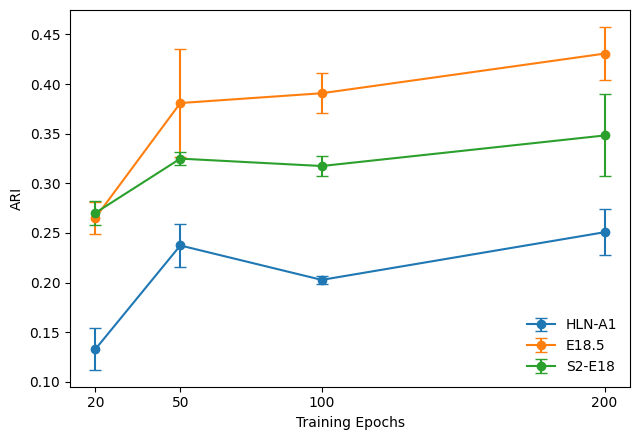

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_ARI.png
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_ARI.pdf


In [15]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(
        6.5,
        4.5,
    )
)

for dataset in (
    TARGET_DATASETS
):

    d = (
        summary_df[
            summary_df[
                "dataset"
            ]
            == dataset
        ]
        .sort_values(
            "epoch"
        )
    )

    plt.errorbar(
        d["epoch"],
        d["ARI_mean"],
        yerr=d["ARI_std"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=dataset,
    )

plt.xticks(
    MILESTONE_EPOCHS
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "ARI"
)

plt.legend(
    frameon=False
)

plt.tight_layout()

ARI_PNG = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_ARI.png"
)

ARI_PDF = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_ARI.pdf"
)

plt.savefig(
    ARI_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    ARI_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:"
)

print(
    ARI_PNG
)

print(
    ARI_PDF
)

Cell 12：画 NMI epoch sensitivity

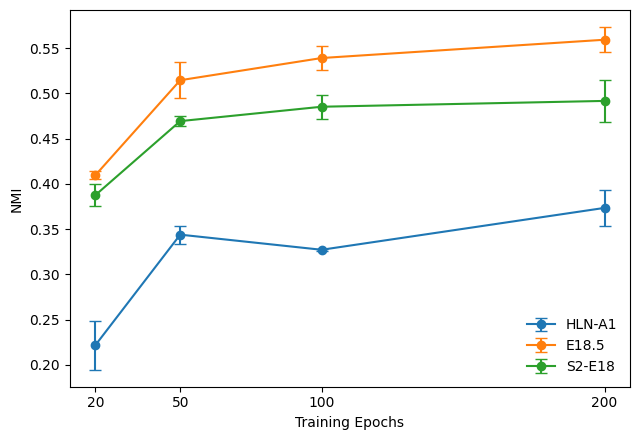

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_NMI.png
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_NMI.pdf


In [16]:
plt.figure(
    figsize=(
        6.5,
        4.5,
    )
)

for dataset in (
    TARGET_DATASETS
):

    d = (
        summary_df[
            summary_df[
                "dataset"
            ]
            == dataset
        ]
        .sort_values(
            "epoch"
        )
    )

    plt.errorbar(
        d["epoch"],
        d["NMI_mean"],
        yerr=d["NMI_std"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=dataset,
    )

plt.xticks(
    MILESTONE_EPOCHS
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "NMI"
)

plt.legend(
    frameon=False
)

plt.tight_layout()

NMI_PNG = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_NMI.png"
)

NMI_PDF = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_NMI.pdf"
)

plt.savefig(
    NMI_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    NMI_PDF,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:"
)

print(
    NMI_PNG
)

print(
    NMI_PDF
)

Cell 13：输出每个 seed 的训练趋势

In [17]:
for dataset in (
    TARGET_DATASETS
):

    print(
        "\n"
        + "=" * 90
    )

    print(
        dataset
    )

    print(
        "=" * 90
    )

    d = raw_df[
        raw_df[
            "dataset"
        ]
        == dataset
    ]

    for seed in (
        TARGET_SEEDS
    ):

        s = (
            d[
                d[
                    "seed"
                ]
                == seed
            ]
            .sort_values(
                "epoch"
            )
        )

        print(
            f"\nSeed {seed}"
        )

        print(
            "-" * 50
        )

        for _, r in (
            s.iterrows()
        ):

            print(
                f"epoch "
                f"{int(r['epoch']):>3d}"
                f" | "
                f"ARI "
                f"{r['ARI']:.6f}"
                f" | "
                f"NMI "
                f"{r['NMI']:.6f}"
            )


HLN-A1

Seed 0
--------------------------------------------------
epoch  20 | ARI 0.113589 | NMI 0.213376
epoch  50 | ARI 0.240303 | NMI 0.336597
epoch 100 | ARI 0.207380 | NMI 0.328553
epoch 200 | ARI 0.228984 | NMI 0.355029

Seed 1
--------------------------------------------------
epoch  20 | ARI 0.161726 | NMI 0.258024
epoch  50 | ARI 0.262458 | NMI 0.357759
epoch 100 | ARI 0.198463 | NMI 0.325898
epoch 200 | ARI 0.282744 | NMI 0.400679

Seed 2
--------------------------------------------------
epoch  20 | ARI 0.123772 | NMI 0.193482
epoch  50 | ARI 0.209465 | NMI 0.337028
epoch 100 | ARI 0.202292 | NMI 0.326798
epoch 200 | ARI 0.240551 | NMI 0.364387

E18.5

Seed 0
--------------------------------------------------
epoch  20 | ARI 0.286885 | NMI 0.411749
epoch  50 | ARI 0.456772 | NMI 0.535868
epoch 100 | ARI 0.392043 | NMI 0.557530
epoch 200 | ARI 0.404423 | NMI 0.553622

Seed 1
--------------------------------------------------
epoch  20 | ARI 0.261776 | NMI 0.413660
epoch  50 

Cell 14：比较相邻 epoch 的变化

In [18]:
delta_rows = []

for dataset in (
    TARGET_DATASETS
):

    d = (
        summary_df[
            summary_df[
                "dataset"
            ]
            == dataset
        ]
        .sort_values(
            "epoch"
        )
        .reset_index(
            drop=True
        )
    )

    for i in range(
        len(d) - 1
    ):

        r1 = d.iloc[i]
        r2 = d.iloc[i + 1]

        delta_rows.append(
            {
                "dataset": dataset,

                "from_epoch": int(
                    r1[
                        "epoch"
                    ]
                ),

                "to_epoch": int(
                    r2[
                        "epoch"
                    ]
                ),

                "delta_ARI": (
                    r2[
                        "ARI_mean"
                    ]
                    -
                    r1[
                        "ARI_mean"
                    ]
                ),

                "delta_NMI": (
                    r2[
                        "NMI_mean"
                    ]
                    -
                    r1[
                        "NMI_mean"
                    ]
                ),
            }
        )


delta_df = pd.DataFrame(
    delta_rows
)

print(
    delta_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.6f}",
    )
)

DELTA_CSV = (
    SENS_SUMMARY_DIR
    / "epoch_sensitivity_deltas.csv"
)

delta_df.to_csv(
    DELTA_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    DELTA_CSV
)

dataset  from_epoch  to_epoch  delta_ARI  delta_NMI
 HLN-A1          20        50  +0.104379  +0.122168
 HLN-A1          50       100  -0.034697  -0.016712
 HLN-A1         100       200  +0.048048  +0.046282
  E18.5          20        50  +0.115476  +0.105005
  E18.5          50       100  +0.009878  +0.024534
  E18.5         100       200  +0.039920  +0.020210
 S2-E18          20        50  +0.054596  +0.081842
 S2-E18          50       100  -0.007452  +0.015883
 S2-E18         100       200  +0.030784  +0.006438

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary/epoch_sensitivity_deltas.csv


Cell 15：找每个数据集平均表现最高的 epoch

In [19]:
analysis_rows = []

for dataset in (
    TARGET_DATASETS
):

    d = summary_df[
        summary_df[
            "dataset"
        ]
        == dataset
    ].copy()

    best_ari_row = d.loc[
        d[
            "ARI_mean"
        ].idxmax()
    ]

    best_nmi_row = d.loc[
        d[
            "NMI_mean"
        ].idxmax()
    ]

    analysis_rows.append(
        {
            "dataset": dataset,

            "best_ARI_epoch": int(
                best_ari_row[
                    "epoch"
                ]
            ),

            "best_ARI": float(
                best_ari_row[
                    "ARI_mean"
                ]
            ),

            "best_NMI_epoch": int(
                best_nmi_row[
                    "epoch"
                ]
            ),

            "best_NMI": float(
                best_nmi_row[
                    "NMI_mean"
                ]
            ),
        }
    )


best_epoch_df = pd.DataFrame(
    analysis_rows
)

print(
    best_epoch_df.to_string(
        index=False
    )
)

print(
    "\nIMPORTANT:"
)

print(
    "This table is diagnostic only."
)

print(
    "Do NOT replace the formal "
    "50-epoch benchmark based on "
    "these test-set ARI/NMI values."
)

dataset  best_ARI_epoch  best_ARI  best_NMI_epoch  best_NMI
 HLN-A1             200  0.250760             200  0.373365
  E18.5             200  0.430720             200  0.559236
 S2-E18             200  0.348236             200  0.491615

IMPORTANT:
This table is diagnostic only.
Do NOT replace the formal 50-epoch benchmark based on these test-set ARI/NMI values.


Cell 16：最终总审计

In [20]:
EXPECTED_RUNS = (
    len(TARGET_DATASETS)
    *
    len(TARGET_SEEDS)
)

EXPECTED_ROWS = (
    len(TARGET_DATASETS)
    *
    len(TARGET_SEEDS)
    *
    len(MILESTONE_EPOCHS)
)

assert EXPECTED_RUNS == 9
assert EXPECTED_ROWS == 36


# ============================================================
# Check all result directories
# ============================================================

completed_runs = 0

for config_path in (
    generated_configs
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    exp_name = cfg[
        "experiment"
    ]["name"]

    result_dir = (
        SENS_RESULT_ROOT
        / exp_name
    )

    assert result_dir.exists(), (
        result_dir
    )

    assert (
        result_dir
        / "metrics.json"
    ).exists()

    for epoch in (
        MILESTONE_EPOCHS
    ):

        assert (
            result_dir
            / f"metrics_epoch{epoch}.json"
        ).exists()

    completed_runs += 1


# ============================================================
# Summary files
# ============================================================

assert RAW_CSV.exists()
assert SUMMARY_CSV.exists()
assert PAPER_CSV.exists()
assert DELTA_CSV.exists()

assert ARI_PNG.exists()
assert ARI_PDF.exists()

assert NMI_PNG.exists()
assert NMI_PDF.exists()

assert len(
    raw_df
) == 36

assert len(
    summary_df
) == 12


# ============================================================
# Print audit
# ============================================================

print(
    "=" * 80
)

print(
    "FINAL EPOCH-SENSITIVITY AUDIT"
)

print(
    "=" * 80
)

print(
    "Datasets:"
)

for dataset in (
    TARGET_DATASETS
):

    print(
        " -",
        dataset,
    )

print(
    "\nSeeds:",
    TARGET_SEEDS,
)

print(
    "Milestones:",
    MILESTONE_EPOCHS,
)

print(
    "\nCompleted runs:",
    completed_runs,
    "/",
    EXPECTED_RUNS,
)

print(
    "Raw metric rows:",
    len(raw_df),
    "/",
    EXPECTED_ROWS,
)

print(
    "Summary rows:",
    len(summary_df),
    "/ 12",
)

print(
    "\nPASS: epoch sensitivity "
    "experiment complete."
)

FINAL EPOCH-SENSITIVITY AUDIT
Datasets:
 - HLN-A1
 - E18.5
 - S2-E18

Seeds: [0, 1, 2]
Milestones: [20, 50, 100, 200]

Completed runs: 9 / 9
Raw metric rows: 36 / 36
Summary rows: 12 / 12

PASS: epoch sensitivity experiment complete.


Cell 17：打包这次 sensitivity 结果

In [21]:
ARCHIVE_DIR = (
    Path(
        "/kaggle/working"
    )
    / "SpaMGCL_epoch_sensitivity_archive"
)

if ARCHIVE_DIR.exists():

    shutil.rmtree(
        ARCHIVE_DIR
    )

ARCHIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. Configs
# ============================================================

archive_configs = (
    ARCHIVE_DIR
    / "configs"
)

archive_configs.mkdir(
    parents=True,
    exist_ok=True,
)

for path in (
    generated_configs
):

    shutil.copy2(
        path,
        archive_configs
        / path.name,
    )


# ============================================================
# 2. Runner
# ============================================================

archive_code = (
    ARCHIVE_DIR
    / "code"
)

archive_code.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    RUNNER_SENS,
    archive_code
    / RUNNER_SENS.name,
)


# ============================================================
# 3. Metrics only
# ============================================================

archive_results = (
    ARCHIVE_DIR
    / "results"
)

archive_results.mkdir(
    parents=True,
    exist_ok=True,
)

metric_names = [
    "metrics.json",
    "metrics_epoch20.json",
    "metrics_epoch50.json",
    "metrics_epoch100.json",
    "metrics_epoch200.json",
]

for config_path in (
    generated_configs
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    exp_name = cfg[
        "experiment"
    ]["name"]

    src_dir = (
        SENS_RESULT_ROOT
        / exp_name
    )

    dst_dir = (
        archive_results
        / exp_name
    )

    dst_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    for filename in (
        metric_names
    ):

        src = (
            src_dir
            / filename
        )

        assert src.exists(), src

        shutil.copy2(
            src,
            dst_dir
            / filename,
        )


# ============================================================
# 4. Summaries / figures
# ============================================================

archive_summary = (
    ARCHIVE_DIR
    / "summary"
)

shutil.copytree(
    SENS_SUMMARY_DIR,
    archive_summary,
    dirs_exist_ok=True,
)


# ============================================================
# 5. Zip
# ============================================================

ZIP_BASE = Path(
    "/kaggle/working/"
    "SpaMGCL_epoch_sensitivity_"
    "3datasets_3seeds"
)

ZIP_PATH = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=ARCHIVE_DIR,
)

ZIP_PATH = Path(
    ZIP_PATH
)

assert ZIP_PATH.exists()

print(
    "Archive:"
)

print(
    ZIP_PATH
)

print(
    "\nSize (MB):",
    round(
        ZIP_PATH.stat().st_size
        / 1024
        / 1024,
        2,
    ),
)

print(
    "\nPASS: sensitivity "
    "results archived."
)



Archive:
/kaggle/working/SpaMGCL_epoch_sensitivity_3datasets_3seeds.zip

Size (MB): 1.07

PASS: sensitivity results archived.


# Continue Epoch Sensitivity: 200 → 400 Epochs

We extend the existing 3-dataset × 3-seed sensitivity experiments
from epoch 200 to epoch 400.

Existing milestones:
20 / 50 / 100 / 200

New milestones:
300 / 400

The continuation restores:
- model state
- optimizer state
- Python RNG state
- NumPy RNG state
- PyTorch RNG state
- CUDA RNG state

Therefore, epochs 201–400 continue from the original epoch-200
training trajectory rather than restarting training from scratch.

Cell 18：先检查 9 个 epoch-200 checkpoint 还在不在

In [22]:
from pathlib import Path
import yaml

PROJECT_ROOT = Path(
    "/kaggle/working/SpaMGCL/SpaMGCL"
)

OLD_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "epoch_sensitivity"
)

OLD_RESULT_ROOT = (
    PROJECT_ROOT
    / "results_sensitivity"
)

CONT_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "epoch_sensitivity_400"
)

CONT_RESULT_ROOT = (
    PROJECT_ROOT
    / "results_sensitivity_400"
)

CONT_SUMMARY_DIR = (
    PROJECT_ROOT
    / "sensitivity_summary_400"
)

CONT_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CONT_RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

CONT_SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TARGET_DATASETS = [
    "HLN-A1",
    "E18.5",
    "S2-E18",
]

TARGET_SEEDS = [
    0,
    1,
    2,
]

ALL_MILESTONES = [
    20,
    50,
    100,
    200,
    300,
    400,
]

DATASET_SLUG = {
    "HLN-A1": "hlna1",
    "E18.5": "e185",
    "S2-E18": "s2e18",
}


checkpoint_rows = []

for dataset in TARGET_DATASETS:

    slug = DATASET_SLUG[dataset]

    for seed in TARGET_SEEDS:

        old_name = (
            f"sens_{slug}_"
            f"seed{seed}_200ep"
        )

        old_dir = (
            OLD_RESULT_ROOT
            / old_name
        )

        checkpoint = (
            old_dir
            / "checkpoint_epoch200.pt"
        )

        metrics200 = (
            old_dir
            / "metrics_epoch200.json"
        )

        checkpoint_rows.append(
            {
                "dataset": dataset,
                "seed": seed,
                "checkpoint": checkpoint,
                "checkpoint_exists": checkpoint.exists(),
                "metrics200_exists": metrics200.exists(),
            }
        )


import pandas as pd

checkpoint_df = pd.DataFrame(
    checkpoint_rows
)

print(
    checkpoint_df[
        [
            "dataset",
            "seed",
            "checkpoint_exists",
            "metrics200_exists",
        ]
    ].to_string(
        index=False
    )
)

assert (
    checkpoint_df[
        "checkpoint_exists"
    ].all()
), (
    "STOP: 至少一个 checkpoint_epoch200.pt 不存在。\n"
    "如果 Kaggle session 已经重启，而你只保留了之前的 ZIP，"
    "那个 ZIP 没有包含 checkpoint，因此不能做精确续训。"
)

assert (
    checkpoint_df[
        "metrics200_exists"
    ].all()
)

print(
    "\nPASS: 9/9 epoch-200 checkpoints are available."
)

dataset  seed  checkpoint_exists  metrics200_exists
 HLN-A1     0               True               True
 HLN-A1     1               True               True
 HLN-A1     2               True               True
  E18.5     0               True               True
  E18.5     1               True               True
  E18.5     2               True               True
 S2-E18     0               True               True
 S2-E18     1               True               True
 S2-E18     2               True               True

PASS: 9/9 epoch-200 checkpoints are available.


Cell 19：创建支持 resume 的 runner

In [23]:
from pathlib import Path
import subprocess
import sys

RUNNER_SENS = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_sensitivity.py"
)

RUNNER_RESUME = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_resume_sensitivity.py"
)

assert RUNNER_SENS.exists()

source = RUNNER_SENS.read_text(
    encoding="utf-8"
)

patched = source


# ============================================================
# Patch 1
# Add 300 / 400 milestones
# ============================================================

old_milestones = (
    "milestone_epochs = "
    "{20, 50, 100, 200}"
)

new_milestones = (
    "milestone_epochs = "
    "{20, 50, 100, 200, 300, 400}"
)

assert old_milestones in patched

patched = patched.replace(
    old_milestones,
    new_milestones,
    1,
)


# ============================================================
# Patch 2
# Insert resume logic after optimizer creation
# ============================================================

marker = (
    '    print(f"Dataset: {dataset} | '
    'spots={sample.n_spots} | device={device}")'
)

assert marker in patched


resume_block = r'''
    # ------------------------------------------------------------
    # Optional exact resume from a saved milestone checkpoint.
    # ------------------------------------------------------------

    resume_from_value = training_config.get(
        "resume_from"
    )

    resume_checkpoint_path = None
    start_epoch = 0
    resume_history = []

    if resume_from_value:

        resume_checkpoint_path = _resolve_path(
            resume_from_value,
            base=PROJECT_ROOT,
            field_name="training.resume_from",
        )

        if not resume_checkpoint_path.is_file():
            raise FileNotFoundError(
                f"Resume checkpoint not found: "
                f"{resume_checkpoint_path}"
            )

        checkpoint = torch.load(
            resume_checkpoint_path,
            map_location=device,
            weights_only=False,
        )

        required_checkpoint_keys = {
            "model",
            "optimizer",
            "epoch",
            "python_rng_state",
            "numpy_rng_state",
            "torch_rng_state",
        }

        missing_checkpoint_keys = (
            required_checkpoint_keys
            - set(checkpoint)
        )

        if missing_checkpoint_keys:
            raise KeyError(
                "Resume checkpoint is missing keys: "
                f"{sorted(missing_checkpoint_keys)}"
            )

        model.load_state_dict(
            checkpoint["model"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer"]
        )

        start_epoch = int(
            checkpoint["epoch"]
        )

        if (
            start_epoch < 0
            or start_epoch >= epochs
        ):
            raise ValueError(
                "Resume epoch must satisfy "
                "0 <= resume_epoch < epochs; "
                f"received "
                f"resume_epoch={start_epoch}, "
                f"epochs={epochs}"
            )

        # Restore RNG AFTER all model/data initialization.
        random.setstate(
            checkpoint[
                "python_rng_state"
            ]
        )

        np.random.set_state(
            checkpoint[
                "numpy_rng_state"
            ]
        )

        torch.set_rng_state(
            checkpoint[
                "torch_rng_state"
            ]
        )

        if (
            torch.cuda.is_available()
            and
            "cuda_rng_state"
            in checkpoint
        ):
            torch.cuda.set_rng_state_all(
                checkpoint[
                    "cuda_rng_state"
                ]
            )

        # Recover epochs 1..200 loss history.
        history_path = (
            resume_checkpoint_path.parent
            / f"metrics_epoch{start_epoch}.json"
        )

        if not history_path.is_file():
            raise FileNotFoundError(
                "Cannot reconstruct "
                "pre-resume loss history: "
                f"{history_path}"
            )

        history_snapshot = json.loads(
            history_path.read_text(
                encoding="utf-8"
            )
        )

        resume_history = list(
            history_snapshot.get(
                "loss_history",
                [],
            )
        )

        if (
            len(resume_history)
            != start_epoch
        ):
            raise RuntimeError(
                "Resume history length "
                "does not match checkpoint epoch: "
                f"len(history)="
                f"{len(resume_history)}, "
                f"checkpoint_epoch="
                f"{start_epoch}"
            )

        if resume_history:

            last_history_epoch = int(
                resume_history[-1][
                    "epoch"
                ]
            )

            if (
                last_history_epoch
                != start_epoch
            ):
                raise RuntimeError(
                    "Resume history ends "
                    "at wrong epoch: "
                    f"{last_history_epoch} "
                    f"!= {start_epoch}"
                )

        print(
            "Resuming training from "
            f"epoch {start_epoch}: "
            f"{resume_checkpoint_path}"
        )

'''


patched = patched.replace(
    marker,
    resume_block + marker,
    1,
)


# ============================================================
# Patch 3
# Start loop from checkpoint epoch
# ============================================================

old_loop = '''    history = []
    cluster_head_init = str(training_config.get("cluster_head_init", "none")).lower()
    cluster_head_initialized = False
    for epoch_index in range(epochs):
'''

new_loop = '''    history = list(resume_history)
    cluster_head_init = str(training_config.get("cluster_head_init", "none")).lower()
    cluster_head_initialized = (
        start_epoch >= warm_up_epochs
        and cluster_head_init == "kmeans"
    )
    for epoch_index in range(start_epoch, epochs):
'''

assert old_loop in patched

patched = patched.replace(
    old_loop,
    new_loop,
    1,
)


# ============================================================
# Patch 4
# Record resume information in metrics.json
# ============================================================

old_report = '''        "epochs": epochs,
        "warm_up_epochs": warm_up_epochs,
'''

new_report = '''        "epochs": epochs,
        "resumed": bool(resume_checkpoint_path is not None),
        "resume_from": (
            str(resume_checkpoint_path)
            if resume_checkpoint_path is not None
            else None
        ),
        "resume_epoch": int(start_epoch),
        "warm_up_epochs": warm_up_epochs,
'''

assert old_report in patched

patched = patched.replace(
    old_report,
    new_report,
    1,
)


# ============================================================
# Save new runner
# ============================================================

RUNNER_RESUME.write_text(
    patched,
    encoding="utf-8",
)


# ============================================================
# Syntax check
# ============================================================

subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(RUNNER_RESUME),
    ],
    check=True,
)


check_text = RUNNER_RESUME.read_text(
    encoding="utf-8"
)

assert (
    "resume_from_value"
    in check_text
)

assert (
    "{20, 50, 100, 200, 300, 400}"
    in check_text
)

assert (
    "range(start_epoch, epochs)"
    in check_text
)

print(
    "Created:"
)

print(
    RUNNER_RESUME
)

print(
    "\nPASS: resume runner created."
)

Created:
/kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_sensitivity.py

PASS: resume runner created.


Cell 20：生成 9 个 400-epoch continuation configs

In [24]:
import copy
import yaml

CONT_CONFIGS = []

for dataset in TARGET_DATASETS:

    slug = DATASET_SLUG[
        dataset
    ]

    for seed in TARGET_SEEDS:

        old_name = (
            f"sens_{slug}_"
            f"seed{seed}_200ep"
        )

        old_config = (
            OLD_CONFIG_DIR
            / f"{old_name}.yaml"
        )

        old_checkpoint = (
            OLD_RESULT_ROOT
            / old_name
            / "checkpoint_epoch200.pt"
        )

        assert old_config.exists()
        assert old_checkpoint.exists()

        with old_config.open(
            "r",
            encoding="utf-8",
        ) as f:

            cfg = yaml.safe_load(f)

        cfg = copy.deepcopy(
            cfg
        )

        new_name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        # ----------------------------------------------
        # Experiment
        # ----------------------------------------------

        cfg[
            "experiment"
        ]["name"] = new_name

        if (
            "epochs"
            in cfg["experiment"]
        ):
            cfg[
                "experiment"
            ]["epochs"] = 400

        # ----------------------------------------------
        # Training
        # ----------------------------------------------

        cfg[
            "training"
        ]["epochs"] = 400

        cfg[
            "training"
        ]["resume_from"] = str(
            old_checkpoint
        )

        # ----------------------------------------------
        # New output root
        # Do NOT overwrite 200-epoch results.
        # ----------------------------------------------

        cfg[
            "output"
        ]["root"] = (
            "results_sensitivity_400"
        )

        # ----------------------------------------------
        # Save
        # ----------------------------------------------

        new_config = (
            CONT_CONFIG_DIR
            / f"{new_name}.yaml"
        )

        with new_config.open(
            "w",
            encoding="utf-8",
        ) as f:

            yaml.safe_dump(
                cfg,
                f,
                sort_keys=False,
                allow_unicode=True,
            )

        CONT_CONFIGS.append(
            new_config
        )


assert len(
    CONT_CONFIGS
) == 9

print(
    "Generated continuation configs:"
)

for p in sorted(
    CONT_CONFIGS
):
    print(
        " -",
        p.name,
    )

print(
    "\nPASS: 9 continuation configs generated."
)

Generated continuation configs:
 - sens_e185_seed0_400ep.yaml
 - sens_e185_seed1_400ep.yaml
 - sens_e185_seed2_400ep.yaml
 - sens_hlna1_seed0_400ep.yaml
 - sens_hlna1_seed1_400ep.yaml
 - sens_hlna1_seed2_400ep.yaml
 - sens_s2e18_seed0_400ep.yaml
 - sens_s2e18_seed1_400ep.yaml
 - sens_s2e18_seed2_400ep.yaml

PASS: 9 continuation configs generated.


Cell 21：正式续训前 audit

In [25]:
import torch

audit_rows = []

for config_path in sorted(
    CONT_CONFIGS
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    epochs = int(
        cfg[
            "training"
        ]["epochs"]
    )

    resume_path = Path(
        cfg[
            "training"
        ]["resume_from"]
    )

    assert resume_path.exists()

    checkpoint = torch.load(
        resume_path,
        map_location="cpu",
        weights_only=False,
    )

    resume_epoch = int(
        checkpoint["epoch"]
    )

    clustering = cfg[
        "clustering"
    ]

    refinement = cfg[
        "refinement"
    ]

    audit_rows.append(
        {
            "dataset": dataset,
            "seed": seed,
            "resume_epoch": resume_epoch,
            "target_epoch": epochs,
            "n_init": int(
                clustering["n_init"]
            ),
            "kmeans_rs": int(
                clustering[
                    "random_state"
                ]
            ),
            "refinement": refinement[
                "method"
            ],
            "spatial_k": int(
                refinement[
                    "spatial_k"
                ]
            ),
        }
    )


resume_audit_df = pd.DataFrame(
    audit_rows
)

print(
    resume_audit_df.to_string(
        index=False
    )
)

assert (
    resume_audit_df[
        "resume_epoch"
    ] == 200
).all()

assert (
    resume_audit_df[
        "target_epoch"
    ] == 400
).all()

assert (
    resume_audit_df[
        "n_init"
    ] == 20
).all()

assert (
    resume_audit_df[
        "kmeans_rs"
    ] == 0
).all()

assert (
    resume_audit_df[
        "refinement"
    ].str.lower()
    == "bsrr"
).all()

assert (
    resume_audit_df[
        "spatial_k"
    ] == 3
).all()

print(
    "\nPASS: all runs will resume "
    "from epoch 200 and stop at 400."
)

dataset  seed  resume_epoch  target_epoch  n_init  kmeans_rs refinement  spatial_k
  E18.5     0           200           400      20          0       bsrr          3
  E18.5     1           200           400      20          0       bsrr          3
  E18.5     2           200           400      20          0       bsrr          3
 HLN-A1     0           200           400      20          0       bsrr          3
 HLN-A1     1           200           400      20          0       bsrr          3
 HLN-A1     2           200           400      20          0       bsrr          3
 S2-E18     0           200           400      20          0       bsrr          3
 S2-E18     1           200           400      20          0       bsrr          3
 S2-E18     2           200           400      20          0       bsrr          3

PASS: all runs will resume from epoch 200 and stop at 400.


修复 RNG state 类型兼容

In [27]:
from pathlib import Path
import subprocess
import sys

RUNNER_RESUME = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_resume_sensitivity.py"
)

assert RUNNER_RESUME.exists(), RUNNER_RESUME

text = RUNNER_RESUME.read_text(
    encoding="utf-8"
)

old_block = '''        torch.set_rng_state(
            checkpoint[
                "torch_rng_state"
            ]
        )

        if (
            torch.cuda.is_available()
            and
            "cuda_rng_state"
            in checkpoint
        ):
            torch.cuda.set_rng_state_all(
                checkpoint[
                    "cuda_rng_state"
                ]
            )
'''

new_block = '''        # --------------------------------------------------------
        # Restore PyTorch RNG states.
        #
        # Some checkpoint versions store RNG states as NumPy
        # arrays / Python lists rather than torch.ByteTensor.
        # PyTorch requires a CPU uint8 tensor here.
        # --------------------------------------------------------

        def _normalize_torch_rng_state(
            state,
            state_name,
        ):
            if torch.is_tensor(state):

                normalized = (
                    state
                    .detach()
                    .cpu()
                    .to(dtype=torch.uint8)
                    .contiguous()
                )

            elif isinstance(
                state,
                np.ndarray,
            ):

                normalized = torch.from_numpy(
                    np.asarray(
                        state,
                        dtype=np.uint8,
                    )
                ).cpu().contiguous()

            elif isinstance(
                state,
                (list, tuple),
            ):

                normalized = torch.tensor(
                    state,
                    dtype=torch.uint8,
                    device="cpu",
                ).contiguous()

            else:

                raise TypeError(
                    f"Unsupported {state_name} type: "
                    f"{type(state)}"
                )

            return normalized


        torch_rng_state = (
            _normalize_torch_rng_state(
                checkpoint[
                    "torch_rng_state"
                ],
                "torch_rng_state",
            )
        )

        torch.set_rng_state(
            torch_rng_state
        )


        if (
            torch.cuda.is_available()
            and
            "cuda_rng_state"
            in checkpoint
        ):

            cuda_states = checkpoint[
                "cuda_rng_state"
            ]

            # cuda_rng_state normally is a list
            # of one RNG state per GPU.
            #
            # Also tolerate a single RNG state.
            if torch.is_tensor(
                cuda_states
            ) or isinstance(
                cuda_states,
                np.ndarray,
            ):

                cuda_states = [
                    cuda_states
                ]

            elif isinstance(
                cuda_states,
                (list, tuple),
            ):

                if len(
                    cuda_states
                ) == 0:

                    raise RuntimeError(
                        "cuda_rng_state is empty"
                    )

                # A flat list of integers means
                # this is one RNG state.
                if isinstance(
                    cuda_states[0],
                    (int, np.integer),
                ):

                    cuda_states = [
                        cuda_states
                    ]

            else:

                raise TypeError(
                    "Unsupported cuda_rng_state "
                    f"type: {type(cuda_states)}"
                )

            normalized_cuda_states = [
                _normalize_torch_rng_state(
                    state,
                    f"cuda_rng_state[{i}]",
                )
                for i, state
                in enumerate(cuda_states)
            ]

            torch.cuda.set_rng_state_all(
                normalized_cuda_states
            )
'''

assert old_block in text, (
    "没有找到旧 RNG restore 代码块。"
    "请不要继续运行训练。"
)

text = text.replace(
    old_block,
    new_block,
    1,
)

RUNNER_RESUME.write_text(
    text,
    encoding="utf-8",
)

# ============================================================
# Syntax check
# ============================================================

subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(RUNNER_RESUME),
    ],
    check=True,
)

check_text = RUNNER_RESUME.read_text(
    encoding="utf-8"
)

assert (
    "_normalize_torch_rng_state"
    in check_text
)

print(
    "PASS: RNG restore compatibility patched."
)

print(
    "Runner:"
)

print(
    RUNNER_RESUME
)

PASS: RNG restore compatibility patched.
Runner:
/kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_sensitivity.py


检查 epoch-200 checkpoint RNG 类型

In [28]:
import torch

test_checkpoint = (
    OLD_RESULT_ROOT
    / "sens_e185_seed0_200ep"
    / "checkpoint_epoch200.pt"
)

assert test_checkpoint.exists()

ckpt = torch.load(
    test_checkpoint,
    map_location="cpu",
    weights_only=False,
)

print("Checkpoint epoch :", ckpt["epoch"])

print(
    "torch_rng_state type :",
    type(
        ckpt["torch_rng_state"]
    ),
)

if (
    "cuda_rng_state"
    in ckpt
):
    print(
        "cuda_rng_state type  :",
        type(
            ckpt["cuda_rng_state"]
        ),
    )

print(
    "model state exists     :",
    "model" in ckpt,
)

print(
    "optimizer state exists :",
    "optimizer" in ckpt,
)

assert int(
    ckpt["epoch"]
) == 200

assert "model" in ckpt
assert "optimizer" in ckpt

print(
    "\nPASS: epoch-200 checkpoint readable."
)

Checkpoint epoch : 200
torch_rng_state type : <class 'torch.Tensor'>
cuda_rng_state type  : <class 'list'>
model state exists     : True
optimizer state exists : True

PASS: epoch-200 checkpoint readable.


Cell 22：正式从 200 续训到 400

In [30]:
import shutil
import subprocess
import sys

TOTAL_RUNS = len(
    CONT_CONFIGS
)

for idx, config_path in enumerate(
    sorted(CONT_CONFIGS),
    start=1,
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    exp_name = cfg[
        "experiment"
    ]["name"]

    dataset = cfg[
        "experiment"
    ]["dataset"]

    seed = int(
        cfg[
            "experiment"
        ]["seed"]
    )

    output_dir = (
        CONT_RESULT_ROOT
        / exp_name
    )

    required_files = [
        output_dir
        / "metrics_epoch300.json",

        output_dir
        / "metrics_epoch400.json",

        output_dir
        / "metrics.json",

        output_dir
        / "checkpoint_epoch400.pt",
    ]

    print(
        "\n" + "=" * 80
    )

    print(
        f"[{idx}/{TOTAL_RUNS}]"
    )

    print(
        "Dataset      :",
        dataset,
    )

    print(
        "Seed         :",
        seed,
    )

    print(
        "Resume epoch : 200"
    )

    print(
        "Target epoch : 400"
    )

    print(
        "Name         :",
        exp_name,
    )

    print(
        "=" * 80
    )


    # ========================================================
    # Complete run -> skip
    # ========================================================

    if all(
        p.exists()
        for p in required_files
    ):

        print(
            "SKIP: complete 400-epoch "
            "result already exists."
        )

        continue


    # ========================================================
    # Safe partial handling
    # ========================================================

    if output_dir.exists():

        protected = [
            output_dir
            / "metrics_epoch300.json",

            output_dir
            / "metrics_epoch400.json",

            output_dir
            / "metrics.json",
        ]

        if any(
            p.exists()
            for p in protected
        ):

            raise RuntimeError(
                "\nSTOP: partial resumed training "
                "result exists:\n"
                f"{output_dir}\n"
                "Do not overwrite it automatically."
            )

        # Only config/manifest residue
        print(
            "Removing pre-training residue:"
        )

        print(
            output_dir
        )

        shutil.rmtree(
            output_dir
        )


    # ========================================================
    # Run
    # ========================================================

    cmd = [
        sys.executable,
        str(RUNNER_RESUME),
        "--config",
        str(config_path),
    ]

    print(
        "\nRunning:"
    )

    print(
        " ".join(cmd)
    )

    print()

    subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        check=True,
    )


    # ========================================================
    # Audit
    # ========================================================

    for p in required_files:

        assert p.exists(), (
            f"Missing: {p}"
        )

    print(
        "\nPASS:",
        exp_name,
    )


print(
    "\n" + "=" * 80
)

print(
    "PASS: all 9 runs extended "
    "from 200 to 400 epochs."
)

print(
    "=" * 80
)


[1/9]
Dataset      : E18.5
Seed         : 0
Resume epoch : 200
Target epoch : 400
Name         : sens_e185_seed0_400ep
Removing pre-training residue:
/kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_400/sens_e185_seed0_400ep

Running:
/usr/bin/python3 /kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_sensitivity.py --config /kaggle/working/SpaMGCL/SpaMGCL/configs/epoch_sensitivity_400/sens_e185_seed0_400ep.yaml

Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_e185_seed0_200ep/checkpoint_epoch200.pt
Dataset: E18.5 | spots=2129 | device=cuda
Modalities: RNA, ATAC | label=Combined_Clusters
Spatial graph: shape=(2129, 2129), nnz=7784
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=16.221050 | rec=0.014619 | mgcl=5.362710 | cluster=1.183034 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.917e-04 | neg_count=4530512 | snf_masked_positions=0 | effC=13.70

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_hlna1_seed0_200ep/checkpoint_epoch200.pt
Dataset: HLN-A1 | spots=3484 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3484, 3484), nnz=13206
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=6.551590 | rec=0.026710 | mgcl=6.282759 | cluster=2.421216 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=6.898e-04 | neg_count=12134772 | snf_masked_positions=0 | effC=9.934 | gradC=9.069e-04
epoch 202/400 | total=6.550967 | rec=0.026586 | mgcl=6.282352 | cluster=2.420288 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=5.429e-04 | neg_count=12134772 | snf_masked_positions=0 | effC=9.933 | gradC=9.001e-04
epoch 203/400 | total=6.549948 | rec=0.026460 | mgcl=6.281548 | cluster=2.419403 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False |

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_hlna1_seed1_200ep/checkpoint_epoch200.pt
Dataset: HLN-A1 | spots=3484 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3484, 3484), nnz=13206
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=6.579624 | rec=0.026263 | mgcl=6.310355 | cluster=2.430056 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=3.624e-04 | neg_count=12134772 | snf_masked_positions=0 | effC=9.936 | gradC=1.039e-03
epoch 202/400 | total=6.577473 | rec=0.026134 | mgcl=6.308487 | cluster=2.428513 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=6.311e-04 | neg_count=12134772 | snf_masked_positions=0 | effC=9.938 | gradC=1.030e-03
epoch 203/400 | total=6.574890 | rec=0.026005 | mgcl=6.306185 | cluster=2.427001 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False |

...

Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_s2e18_seed0_200ep/checkpoint_epoch200.pt
Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=16.653919 | rec=0.015395 | mgcl=5.500114 | cluster=1.381802 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=6.917e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.612 | gradC=1.232e-03
epoch 202/400 | total=16.648581 | rec=0.015296 | mgcl=5.498447 | cluster=1.379451 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.365e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.617 | gradC=1.219e-03
epoch 203/400 | total=16.604420 | rec=0.015187 | mgcl=5.483833 | cluster=1.377347 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=Fals

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_s2e18_seed1_200ep/checkpoint_epoch200.pt
Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=16.582287 | rec=0.015092 | mgcl=5.477168 | cluster=1.356918 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.845e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.850 | gradC=1.196e-03
epoch 202/400 | total=16.574606 | rec=0.014995 | mgcl=5.474709 | cluster=1.354824 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=6.116e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.854 | gradC=1.190e-03
epoch 203/400 | total=16.554024 | rec=0.014884 | mgcl=5.467948 | cluster=1.352965 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=Fals

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Resuming training from epoch 200: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity/sens_s2e18_seed2_200ep/checkpoint_epoch200.pt
Dataset: S2-E18 | spots=2248 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(2248, 2248), nnz=8286
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 201/400 | total=16.602764 | rec=0.014972 | mgcl=5.483114 | cluster=1.384498 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.106e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.761 | gradC=1.318e-03
epoch 202/400 | total=16.593843 | rec=0.014861 | mgcl=5.480265 | cluster=1.381868 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=9.133e-04 | neg_count=5051256 | snf_masked_positions=0 | effC=15.765 | gradC=1.299e-03
epoch 203/400 | total=16.581993 | rec=0.014754 | mgcl=5.476427 | cluster=1.379578 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=Fals

Cell 23：合并 20/50/100/200/300/400 共 54 个结果

In [31]:
import json

rows = []

for dataset in TARGET_DATASETS:

    slug = DATASET_SLUG[
        dataset
    ]

    for seed in TARGET_SEEDS:

        old_name = (
            f"sens_{slug}_"
            f"seed{seed}_200ep"
        )

        new_name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        old_dir = (
            OLD_RESULT_ROOT
            / old_name
        )

        new_dir = (
            CONT_RESULT_ROOT
            / new_name
        )


        # ====================================================
        # Old milestones
        # ====================================================

        for epoch in [
            20,
            50,
            100,
            200,
        ]:

            path = (
                old_dir
                / f"metrics_epoch{epoch}.json"
            )

            assert path.exists()

            with path.open(
                "r",
                encoding="utf-8",
            ) as f:

                m = json.load(f)

            rows.append(
                {
                    "dataset": dataset,
                    "seed": seed,
                    "epoch": epoch,
                    "ARI": float(
                        m["ARI"]
                    ),
                    "NMI": float(
                        m["NMI"]
                    ),
                }
            )


        # ====================================================
        # New milestones
        # ====================================================

        for epoch in [
            300,
            400,
        ]:

            path = (
                new_dir
                / f"metrics_epoch{epoch}.json"
            )

            assert path.exists()

            with path.open(
                "r",
                encoding="utf-8",
            ) as f:

                m = json.load(f)

            rows.append(
                {
                    "dataset": dataset,
                    "seed": seed,
                    "epoch": epoch,
                    "ARI": float(
                        m["ARI"]
                    ),
                    "NMI": float(
                        m["NMI"]
                    ),
                }
            )


raw400_df = pd.DataFrame(
    rows
)

raw400_df = (
    raw400_df
    .sort_values(
        [
            "dataset",
            "seed",
            "epoch",
        ]
    )
    .reset_index(
        drop=True
    )
)

assert len(
    raw400_df
) == 54

print(
    raw400_df.to_string(
        index=False
    )
)

RAW400_CSV = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_raw_54rows.csv"
)

raw400_df.to_csv(
    RAW400_CSV,
    index=False,
)

print(
    "\nPASS: 54 milestone "
    "results collected."
)

dataset  seed  epoch      ARI      NMI
  E18.5     0     20 0.286885 0.411749
  E18.5     0     50 0.456772 0.535868
  E18.5     0    100 0.392043 0.557530
  E18.5     0    200 0.404423 0.553622
  E18.5     0    300 0.399333 0.553813
  E18.5     0    400 0.428033 0.559125
  E18.5     1     20 0.261776 0.413660
  E18.5     1     50 0.331956 0.488507
  E18.5     1    100 0.414990 0.526616
  E18.5     1    200 0.420405 0.545679
  E18.5     1    300 0.398375 0.562000
  E18.5     1    400 0.425883 0.561373
  E18.5     2     20 0.247672 0.403051
  E18.5     2     50 0.354035 0.519101
  E18.5     2    100 0.365366 0.532932
  E18.5     2    200 0.467330 0.578406
  E18.5     2    300 0.403261 0.538616
  E18.5     2    400 0.514610 0.589656
 HLN-A1     0     20 0.113589 0.213376
 HLN-A1     0     50 0.240303 0.336597
 HLN-A1     0    100 0.207380 0.328553
 HLN-A1     0    200 0.228984 0.355029
 HLN-A1     0    300 0.221705 0.357496
 HLN-A1     0    400 0.224735 0.357979
 HLN-A1     1     20 0.16

Cell 24：重新计算 6 个 epoch 的 mean ± std

In [32]:
import numpy as np

summary_rows = []

for (
    dataset,
    epoch,
), g in raw400_df.groupby(
    [
        "dataset",
        "epoch",
    ],
    sort=False,
):

    ari = g[
        "ARI"
    ].to_numpy(
        dtype=float
    )

    nmi = g[
        "NMI"
    ].to_numpy(
        dtype=float
    )

    assert len(ari) == 3
    assert len(nmi) == 3

    summary_rows.append(
        {
            "dataset": dataset,
            "epoch": int(epoch),

            "ARI_mean": float(
                np.mean(ari)
            ),

            "ARI_std": float(
                np.std(
                    ari,
                    ddof=0,
                )
            ),

            "NMI_mean": float(
                np.mean(nmi)
            ),

            "NMI_std": float(
                np.std(
                    nmi,
                    ddof=0,
                )
            ),
        }
    )


summary400_df = pd.DataFrame(
    summary_rows
)

dataset_order = {
    "HLN-A1": 0,
    "E18.5": 1,
    "S2-E18": 2,
}

summary400_df[
    "_order"
] = (
    summary400_df[
        "dataset"
    ].map(
        dataset_order
    )
)

summary400_df = (
    summary400_df
    .sort_values(
        [
            "_order",
            "epoch",
        ]
    )
    .drop(
        columns="_order"
    )
    .reset_index(
        drop=True
    )
)


print(
    "=" * 100
)

print(
    "EPOCH SENSITIVITY "
    "20 / 50 / 100 / 200 / 300 / 400"
)

print(
    "=" * 100
)

for _, r in (
    summary400_df.iterrows()
):

    print(
        f"{r['dataset']:8s} | "
        f"epoch "
        f"{int(r['epoch']):>3d} | "
        f"ARI = "
        f"{r['ARI_mean']:.6f} "
        f"± "
        f"{r['ARI_std']:.6f} | "
        f"NMI = "
        f"{r['NMI_mean']:.6f} "
        f"± "
        f"{r['NMI_std']:.6f}"
    )


SUMMARY400_CSV = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_summary_400.csv"
)

summary400_df.to_csv(
    SUMMARY400_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    SUMMARY400_CSV
)

EPOCH SENSITIVITY 20 / 50 / 100 / 200 / 300 / 400
HLN-A1   | epoch  20 | ARI = 0.133029 ± 0.020713 | NMI = 0.221627 ± 0.026988
HLN-A1   | epoch  50 | ARI = 0.237409 ± 0.021731 | NMI = 0.343795 ± 0.009876
HLN-A1   | epoch 100 | ARI = 0.202712 ± 0.003653 | NMI = 0.327083 ± 0.001102
HLN-A1   | epoch 200 | ARI = 0.250760 ± 0.023104 | NMI = 0.373365 ± 0.019688
HLN-A1   | epoch 300 | ARI = 0.258779 ± 0.026241 | NMI = 0.385866 ± 0.020200
HLN-A1   | epoch 400 | ARI = 0.256884 ± 0.022733 | NMI = 0.383328 ± 0.018015
E18.5    | epoch  20 | ARI = 0.265445 ± 0.016217 | NMI = 0.409487 ± 0.004617
E18.5    | epoch  50 | ARI = 0.380921 ± 0.054387 | NMI = 0.514492 ± 0.019608
E18.5    | epoch 100 | ARI = 0.390799 ± 0.020278 | NMI = 0.539026 ± 0.013336
E18.5    | epoch 200 | ARI = 0.430720 ± 0.026697 | NMI = 0.559236 ± 0.013938
E18.5    | epoch 300 | ARI = 0.400323 ± 0.002114 | NMI = 0.551477 ± 0.009689
E18.5    | epoch 400 | ARI = 0.456175 ± 0.041329 | NMI = 0.570051 ± 0.013893
S2-E18   | epoch  20 | ARI

Cell 25：重新画 ARI 曲线

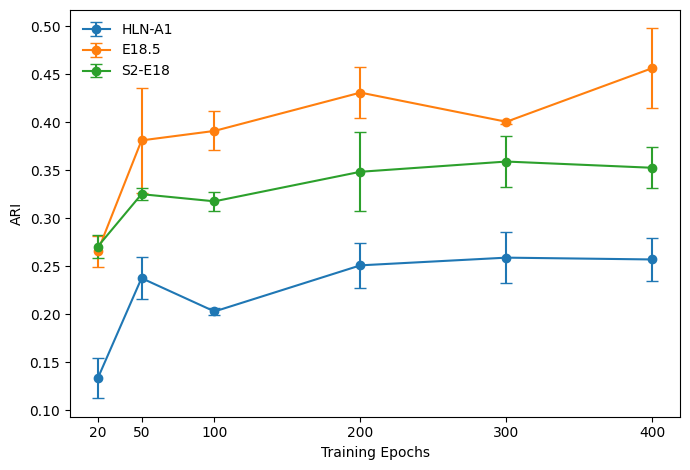

In [33]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(7, 4.8)
)

for dataset in TARGET_DATASETS:

    d = (
        summary400_df[
            summary400_df[
                "dataset"
            ] == dataset
        ]
        .sort_values(
            "epoch"
        )
    )

    plt.errorbar(
        d["epoch"],
        d["ARI_mean"],
        yerr=d["ARI_std"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=dataset,
    )

plt.xticks(
    ALL_MILESTONES
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "ARI"
)

plt.legend(
    frameon=False
)

plt.tight_layout()

ARI400_PNG = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_ARI_400.png"
)

ARI400_PDF = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_ARI_400.pdf"
)

plt.savefig(
    ARI400_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    ARI400_PDF,
    bbox_inches="tight",
)

plt.show()

Cell 26：重新画 NMI 曲线

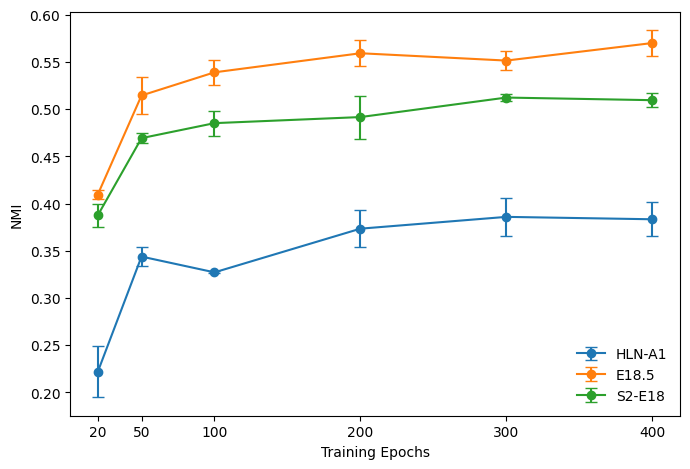

In [34]:
plt.figure(
    figsize=(7, 4.8)
)

for dataset in TARGET_DATASETS:

    d = (
        summary400_df[
            summary400_df[
                "dataset"
            ] == dataset
        ]
        .sort_values(
            "epoch"
        )
    )

    plt.errorbar(
        d["epoch"],
        d["NMI_mean"],
        yerr=d["NMI_std"],
        marker="o",
        capsize=4,
        linewidth=1.5,
        label=dataset,
    )

plt.xticks(
    ALL_MILESTONES
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "NMI"
)

plt.legend(
    frameon=False
)

plt.tight_layout()

NMI400_PNG = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_NMI_400.png"
)

NMI400_PDF = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_NMI_400.pdf"
)

plt.savefig(
    NMI400_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    NMI400_PDF,
    bbox_inches="tight",
)

plt.show()

Cell 27：重点看 200→300→400 的变化

In [35]:
late_rows = []

for dataset in TARGET_DATASETS:

    d = (
        summary400_df[
            summary400_df[
                "dataset"
            ] == dataset
        ]
        .set_index(
            "epoch"
        )
    )

    for from_epoch, to_epoch in [
        (200, 300),
        (300, 400),
        (200, 400),
    ]:

        late_rows.append(
            {
                "dataset": dataset,

                "from_epoch": from_epoch,

                "to_epoch": to_epoch,

                "delta_ARI": (
                    d.loc[
                        to_epoch,
                        "ARI_mean",
                    ]
                    -
                    d.loc[
                        from_epoch,
                        "ARI_mean",
                    ]
                ),

                "delta_NMI": (
                    d.loc[
                        to_epoch,
                        "NMI_mean",
                    ]
                    -
                    d.loc[
                        from_epoch,
                        "NMI_mean",
                    ]
                ),
            }
        )


late_delta_df = pd.DataFrame(
    late_rows
)

print(
    late_delta_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.6f}",
    )
)

LATE_DELTA_CSV = (
    CONT_SUMMARY_DIR
    / "epoch_sensitivity_200_300_400_deltas.csv"
)

late_delta_df.to_csv(
    LATE_DELTA_CSV,
    index=False,
)

dataset  from_epoch  to_epoch  delta_ARI  delta_NMI
 HLN-A1         200       300  +0.008019  +0.012501
 HLN-A1         300       400  -0.001895  -0.002539
 HLN-A1         200       400  +0.006124  +0.009963
  E18.5         200       300  -0.030396  -0.007759
  E18.5         300       400  +0.055852  +0.018575
  E18.5         200       400  +0.025456  +0.010815
 S2-E18         200       300  +0.010651  +0.020670
 S2-E18         300       400  -0.006486  -0.002776
 S2-E18         200       400  +0.004165  +0.017893


Cell 28：找每个数据集 6 个 epoch 中最高点

In [36]:
best_rows = []

for dataset in TARGET_DATASETS:

    d = summary400_df[
        summary400_df[
            "dataset"
        ] == dataset
    ]

    ari_best = d.loc[
        d["ARI_mean"].idxmax()
    ]

    nmi_best = d.loc[
        d["NMI_mean"].idxmax()
    ]

    best_rows.append(
        {
            "dataset": dataset,

            "best_ARI_epoch": int(
                ari_best[
                    "epoch"
                ]
            ),

            "best_ARI": float(
                ari_best[
                    "ARI_mean"
                ]
            ),

            "best_NMI_epoch": int(
                nmi_best[
                    "epoch"
                ]
            ),

            "best_NMI": float(
                nmi_best[
                    "NMI_mean"
                ]
            ),
        }
    )


best400_df = pd.DataFrame(
    best_rows
)

print(
    best400_df.to_string(
        index=False
    )
)

print(
    "\nDiagnostic only — "
    "do not choose a different "
    "epoch for each dataset."
)

dataset  best_ARI_epoch  best_ARI  best_NMI_epoch  best_NMI
 HLN-A1             300  0.258779             300  0.385866
  E18.5             400  0.456175             400  0.570051
 S2-E18             300  0.358887             300  0.512285

Diagnostic only — do not choose a different epoch for each dataset.


Cell 29：这次归档一定保存 epoch-400 checkpoint

In [37]:
import shutil

ARCHIVE400_DIR = (
    Path(
        "/kaggle/working"
    )
    / "SpaMGCL_epoch_sensitivity_400_archive"
)

if ARCHIVE400_DIR.exists():

    shutil.rmtree(
        ARCHIVE400_DIR
    )

ARCHIVE400_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Configs
# ============================================================

archive_configs = (
    ARCHIVE400_DIR
    / "configs"
)

archive_configs.mkdir(
    parents=True,
    exist_ok=True,
)

for p in CONT_CONFIGS:

    shutil.copy2(
        p,
        archive_configs
        / p.name,
    )


# ============================================================
# Resume runner
# ============================================================

archive_code = (
    ARCHIVE400_DIR
    / "code"
)

archive_code.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    RUNNER_RESUME,
    archive_code
    / RUNNER_RESUME.name,
)


# ============================================================
# Results + epoch400 checkpoint
# ============================================================

archive_results = (
    ARCHIVE400_DIR
    / "results"
)

archive_results.mkdir(
    parents=True,
    exist_ok=True,
)


for dataset in TARGET_DATASETS:

    slug = DATASET_SLUG[
        dataset
    ]

    for seed in TARGET_SEEDS:

        name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        src_dir = (
            CONT_RESULT_ROOT
            / name
        )

        dst_dir = (
            archive_results
            / name
        )

        dst_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        files_to_keep = [
            "metrics_epoch300.json",
            "metrics_epoch400.json",
            "metrics.json",

            # Very important:
            "checkpoint_epoch400.pt",
        ]

        for filename in files_to_keep:

            src = (
                src_dir
                / filename
            )

            assert src.exists(), src

            shutil.copy2(
                src,
                dst_dir
                / filename,
            )


# ============================================================
# Summary
# ============================================================

shutil.copytree(
    CONT_SUMMARY_DIR,
    ARCHIVE400_DIR
    / "summary",
    dirs_exist_ok=True,
)


# ============================================================
# ZIP
# ============================================================

ZIP400_BASE = Path(
    "/kaggle/working/"
    "SpaMGCL_epoch_sensitivity_"
    "3datasets_3seeds_400ep"
)

ZIP400_PATH = shutil.make_archive(
    str(ZIP400_BASE),
    "zip",
    root_dir=ARCHIVE400_DIR,
)

ZIP400_PATH = Path(
    ZIP400_PATH
)

print(
    "Archive:"
)

print(
    ZIP400_PATH
)

print(
    "\nSize (MB):",
    round(
        ZIP400_PATH.stat().st_size
        / 1024
        / 1024,
        2,
    ),
)

print(
    "\nPASS: 400-epoch continuation archived "
    "WITH epoch-400 checkpoints."
)

Archive:
/kaggle/working/SpaMGCL_epoch_sensitivity_3datasets_3seeds_400ep.zip

Size (MB): 25.79

PASS: 400-epoch continuation archived WITH epoch-400 checkpoints.


Cell 30：定义 E18.5 400→600 路径

In [38]:
from pathlib import Path

E185_600_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "epoch_sensitivity_e185_600"
)

E185_600_RESULT_ROOT = (
    PROJECT_ROOT
    / "results_sensitivity_e185_600"
)

E185_600_SUMMARY_DIR = (
    PROJECT_ROOT
    / "sensitivity_summary_e185_600"
)

E185_600_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

E185_600_RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

E185_600_SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

E185_SEEDS = [0, 1, 2]

E185_ALL_EPOCHS = [
    20,
    50,
    100,
    200,
    300,
    400,
    500,
    600,
]

print("PASS: E18.5 600-epoch paths ready.")

PASS: E18.5 600-epoch paths ready.


Cell 31：创建 600-epoch resume runner

In [39]:
import subprocess
import sys

RUNNER_400 = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_resume_sensitivity.py"
)

RUNNER_600 = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_resume_e185_600.py"
)

assert RUNNER_400.exists()

text = RUNNER_400.read_text(
    encoding="utf-8"
)

old_milestones = (
    "{20, 50, 100, 200, 300, 400}"
)

new_milestones = (
    "{20, 50, 100, 200, 300, 400, 500, 600}"
)

assert old_milestones in text, (
    "Cannot find 400-epoch milestone set."
)

text = text.replace(
    old_milestones,
    new_milestones,
    1,
)

RUNNER_600.write_text(
    text,
    encoding="utf-8",
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "py_compile",
        str(RUNNER_600),
    ],
    check=True,
)

check_text = RUNNER_600.read_text(
    encoding="utf-8"
)

assert (
    "{20, 50, 100, 200, 300, 400, 500, 600}"
    in check_text
)

assert (
    "range(start_epoch, epochs)"
    in check_text
)

assert (
    "_normalize_torch_rng_state"
    in check_text
)

print("Created:")
print(RUNNER_600)

print(
    "\nPASS: E18.5 600-epoch resume runner created."
)

Created:
/kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_e185_600.py

PASS: E18.5 600-epoch resume runner created.


Cell 32：生成 E18.5 × 3 seeds 的 600-epoch configs

In [40]:
import copy
import yaml

E185_600_CONFIGS = []

for seed in E185_SEEDS:

    old_name = (
        f"sens_e185_seed{seed}_400ep"
    )

    old_config = (
        CONT_CONFIG_DIR
        / f"{old_name}.yaml"
    )

    checkpoint400 = (
        CONT_RESULT_ROOT
        / old_name
        / "checkpoint_epoch400.pt"
    )

    assert old_config.exists(), old_config
    assert checkpoint400.exists(), checkpoint400

    with old_config.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    cfg = copy.deepcopy(cfg)

    new_name = (
        f"sens_e185_seed{seed}_600ep"
    )

    # ---------------------------------------------
    # Experiment
    # ---------------------------------------------

    cfg["experiment"]["name"] = new_name

    if "epochs" in cfg["experiment"]:
        cfg["experiment"]["epochs"] = 600

    # ---------------------------------------------
    # Training
    # ---------------------------------------------

    cfg["training"]["epochs"] = 600

    cfg["training"]["resume_from"] = str(
        checkpoint400
    )

    # ---------------------------------------------
    # Separate output root
    # ---------------------------------------------

    cfg["output"]["root"] = (
        "results_sensitivity_e185_600"
    )

    new_config = (
        E185_600_CONFIG_DIR
        / f"{new_name}.yaml"
    )

    with new_config.open(
        "w",
        encoding="utf-8",
    ) as f:

        yaml.safe_dump(
            cfg,
            f,
            sort_keys=False,
            allow_unicode=True,
        )

    E185_600_CONFIGS.append(
        new_config
    )


assert len(E185_600_CONFIGS) == 3

for p in E185_600_CONFIGS:
    print(p.name)

print(
    "\nPASS: 3 E18.5 continuation configs generated."
)

sens_e185_seed0_600ep.yaml
sens_e185_seed1_600ep.yaml
sens_e185_seed2_600ep.yaml

PASS: 3 E18.5 continuation configs generated.


Cell 33：简单 protocol audit

In [41]:
import torch
import pandas as pd

audit_rows = []

for config_path in sorted(
    E185_600_CONFIGS
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)

    seed = int(
        cfg["experiment"]["seed"]
    )

    resume_path = Path(
        cfg["training"]["resume_from"]
    )

    checkpoint = torch.load(
        resume_path,
        map_location="cpu",
        weights_only=False,
    )

    audit_rows.append(
        {
            "dataset":
                cfg["experiment"]["dataset"],

            "seed":
                seed,

            "resume_epoch":
                int(checkpoint["epoch"]),

            "target_epoch":
                int(cfg["training"]["epochs"]),

            "n_init":
                int(cfg["clustering"]["n_init"]),

            "kmeans_rs":
                int(
                    cfg["clustering"][
                        "random_state"
                    ]
                ),

            "refinement":
                cfg["refinement"]["method"],

            "spatial_k":
                int(
                    cfg["refinement"][
                        "spatial_k"
                    ]
                ),
        }
    )


audit600_df = pd.DataFrame(
    audit_rows
)

print(
    audit600_df.to_string(
        index=False
    )
)

assert (
    audit600_df["dataset"]
    == "E18.5"
).all()

assert (
    audit600_df["resume_epoch"]
    == 400
).all()

assert (
    audit600_df["target_epoch"]
    == 600
).all()

assert (
    audit600_df["n_init"]
    == 20
).all()

assert (
    audit600_df["kmeans_rs"]
    == 0
).all()

assert (
    audit600_df["refinement"]
    .str.lower()
    == "bsrr"
).all()

assert (
    audit600_df["spatial_k"]
    == 3
).all()

print(
    "\nPASS: E18.5 will resume "
    "from 400 and stop at 600."
)

dataset  seed  resume_epoch  target_epoch  n_init  kmeans_rs refinement  spatial_k
  E18.5     0           400           600      20          0       bsrr          3
  E18.5     1           400           600      20          0       bsrr          3
  E18.5     2           400           600      20          0       bsrr          3

PASS: E18.5 will resume from 400 and stop at 600.


Cell 34：正式跑 E18.5 400→600

In [45]:
# ============================================================
# Cell 34：E18.5 400 → 600
# 支持：
#   1. 400 → 600
#   2. 中断后 500 → 600
#   3. 已完成自动 skip
# ============================================================

import copy
import shutil
import subprocess
import sys
import yaml
from pathlib import Path


TOTAL_RUNS = len(
    E185_600_CONFIGS
)

assert TOTAL_RUNS == 3


for idx, config_path in enumerate(
    sorted(E185_600_CONFIGS),
    start=1,
):

    # --------------------------------------------------------
    # Load original continuation config
    # --------------------------------------------------------

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)


    exp_name = (
        cfg["experiment"]["name"]
    )

    seed = int(
        cfg["experiment"]["seed"]
    )

    output_dir = (
        E185_600_RESULT_ROOT
        / exp_name
    )


    # --------------------------------------------------------
    # Important files
    # --------------------------------------------------------

    metrics500 = (
        output_dir
        / "metrics_epoch500.json"
    )

    checkpoint500 = (
        output_dir
        / "checkpoint_epoch500.pt"
    )

    metrics600 = (
        output_dir
        / "metrics_epoch600.json"
    )

    checkpoint600 = (
        output_dir
        / "checkpoint_epoch600.pt"
    )

    final_metrics = (
        output_dir
        / "metrics.json"
    )


    required_final_files = [
        metrics500,
        metrics600,
        final_metrics,
        checkpoint600,
    ]


    print(
        "\n" + "=" * 80
    )

    print(
        f"[{idx}/{TOTAL_RUNS}]"
    )

    print(
        "Dataset : E18.5"
    )

    print(
        "Seed    :",
        seed,
    )

    print(
        "Name    :",
        exp_name,
    )

    print(
        "Output  :",
        output_dir,
    )

    print(
        "=" * 80
    )


    # ========================================================
    # Case 1
    # Complete 600-epoch result already exists
    # ========================================================

    if all(
        p.exists()
        for p in required_final_files
    ):

        print(
            "SKIP: complete 600-epoch "
            "result already exists."
        )

        continue


    # ========================================================
    # Case 2
    # Already reached epoch 500 successfully
    # -> resume from checkpoint 500
    # ========================================================

    if (
        metrics500.exists()
        and checkpoint500.exists()
        and not metrics600.exists()
        and not final_metrics.exists()
    ):

        print(
            "\nDetected completed epoch 500."
        )

        print(
            "metrics500    :",
            metrics500,
        )

        print(
            "checkpoint500 :",
            checkpoint500,
        )

        print(
            "\nResume path:"
        )

        print(
            "500 -> 600"
        )


        # ----------------------------------------------------
        # Make temporary resume-500 config
        #
        # Important:
        # experiment.name remains unchanged,
        # so results continue into SAME directory.
        # ----------------------------------------------------

        resume_cfg = copy.deepcopy(
            cfg
        )

        resume_cfg[
            "training"
        ][
            "resume_from"
        ] = str(
            checkpoint500
        )

        resume_cfg[
            "training"
        ][
            "epochs"
        ] = 600

        if (
            "epochs"
            in resume_cfg[
                "experiment"
            ]
        ):

            resume_cfg[
                "experiment"
            ][
                "epochs"
            ] = 600


        resume500_config = (
            E185_600_CONFIG_DIR
            / (
                f"{exp_name}"
                "_resume500.yaml"
            )
        )


        with resume500_config.open(
            "w",
            encoding="utf-8",
        ) as f:

            yaml.safe_dump(
                resume_cfg,
                f,
                sort_keys=False,
                allow_unicode=True,
            )


        cmd = [
            sys.executable,
            str(RUNNER_600),
            "--config",
            str(resume500_config),
        ]


        print(
            "\nRunning:"
        )

        print(
            " ".join(cmd)
        )

        print()


        subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            check=True,
        )


    # ========================================================
    # Case 3
    # Only pre-training residue exists
    # -> remove and resume normally from epoch 400
    # ========================================================

    else:

        # ----------------------------------------------------
        # Detect dangerous inconsistent partial state
        # ----------------------------------------------------

        trained_files = [
            metrics500,
            checkpoint500,
            metrics600,
            checkpoint600,
            final_metrics,
        ]

        existing_trained_files = [
            p
            for p in trained_files
            if p.exists()
        ]


        if existing_trained_files:

            print(
                "\nInconsistent partial "
                "training state detected:"
            )

            for p in existing_trained_files:

                print(
                    " -",
                    p.name,
                )


            raise RuntimeError(
                "\nSTOP: partial result "
                "cannot be resumed safely "
                "with the current files.\n"
                f"{output_dir}"
            )


        # ----------------------------------------------------
        # No real training result:
        # remove config/manifest residue
        # ----------------------------------------------------

        if output_dir.exists():

            print(
                "\nOnly pre-training "
                "residue detected:"
            )

            for p in sorted(
                output_dir.iterdir()
            ):

                print(
                    " -",
                    p.name,
                )


            print(
                "\nRemoving safe residue..."
            )

            shutil.rmtree(
                output_dir
            )

            print(
                "PASS: residue removed."
            )


        # ----------------------------------------------------
        # Original config resumes from epoch 400
        # ----------------------------------------------------

        print(
            "\nResume path:"
        )

        print(
            "400 -> 600"
        )


        cmd = [
            sys.executable,
            str(RUNNER_600),
            "--config",
            str(config_path),
        ]


        print(
            "\nRunning:"
        )

        print(
            " ".join(cmd)
        )

        print()


        subprocess.run(
            cmd,
            cwd=PROJECT_ROOT,
            check=True,
        )


    # ========================================================
    # Final audit for this seed
    # ========================================================

    for p in required_final_files:

        assert p.exists(), (
            f"Missing result: {p}"
        )


    print(
        "\nSaved:"
    )

    print(
        " - metrics_epoch500.json"
    )

    print(
        " - metrics_epoch600.json"
    )

    print(
        " - checkpoint_epoch600.pt"
    )

    print(
        " - metrics.json"
    )


    print(
        "\nPASS:",
        exp_name,
    )


print(
    "\n" + "=" * 80
)

print(
    "PASS: all E18.5 seeds "
    "completed through epoch 600."
)

print(
    "=" * 80
)


[1/3]
Dataset : E18.5
Seed    : 0
Name    : sens_e185_seed0_600ep
Output  : /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_e185_600/sens_e185_seed0_600ep

Detected completed epoch 500.
metrics500    : /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_e185_600/sens_e185_seed0_600ep/metrics_epoch500.json
checkpoint500 : /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_e185_600/sens_e185_seed0_600ep/checkpoint_epoch500.pt

Resume path:
500 -> 600

Running:
/usr/bin/python3 /kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_e185_600.py --config /kaggle/working/SpaMGCL/SpaMGCL/configs/epoch_sensitivity_e185_600/sens_e185_seed0_600ep_resume500.yaml

Resuming training from epoch 500: /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_e185_600/sens_e185_seed0_600ep/checkpoint_epoch500.pt
Dataset: E18.5 | spots=2129 | device=cuda
Modalities: RNA, ATAC | label=Combined_Clusters
Spatial graph: shape=(2129, 2129), nnz=7784
Learning rates: backbone=0.001 | cluster_head=0.008 (8x

Cell 35：合并 E18.5 的 20→600 全部结果

In [46]:
import json
import pandas as pd

rows = []

for seed in E185_SEEDS:

    # ========================================================
    # 20 / 50 / 100 / 200
    # ========================================================

    old_name = (
        f"sens_e185_seed{seed}_200ep"
    )

    old_dir = (
        OLD_RESULT_ROOT
        / old_name
    )

    for epoch in [
        20,
        50,
        100,
        200,
    ]:

        path = (
            old_dir
            / f"metrics_epoch{epoch}.json"
        )

        assert path.exists(), path

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            m = json.load(f)

        rows.append(
            {
                "dataset": "E18.5",
                "seed": seed,
                "epoch": epoch,
                "ARI": float(m["ARI"]),
                "NMI": float(m["NMI"]),
            }
        )

    # ========================================================
    # 300 / 400
    # ========================================================

    name400 = (
        f"sens_e185_seed{seed}_400ep"
    )

    dir400 = (
        CONT_RESULT_ROOT
        / name400
    )

    for epoch in [
        300,
        400,
    ]:

        path = (
            dir400
            / f"metrics_epoch{epoch}.json"
        )

        assert path.exists(), path

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            m = json.load(f)

        rows.append(
            {
                "dataset": "E18.5",
                "seed": seed,
                "epoch": epoch,
                "ARI": float(m["ARI"]),
                "NMI": float(m["NMI"]),
            }
        )

    # ========================================================
    # 500 / 600
    # ========================================================

    name600 = (
        f"sens_e185_seed{seed}_600ep"
    )

    dir600 = (
        E185_600_RESULT_ROOT
        / name600
    )

    for epoch in [
        500,
        600,
    ]:

        path = (
            dir600
            / f"metrics_epoch{epoch}.json"
        )

        assert path.exists(), path

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            m = json.load(f)

        rows.append(
            {
                "dataset": "E18.5",
                "seed": seed,
                "epoch": epoch,
                "ARI": float(m["ARI"]),
                "NMI": float(m["NMI"]),
            }
        )


e185_raw600_df = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "seed",
            "epoch",
        ]
    )
    .reset_index(
        drop=True
    )
)

assert len(
    e185_raw600_df
) == 24

print(
    e185_raw600_df.to_string(
        index=False
    )
)

RAW600_CSV = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_raw_24rows.csv"
)

e185_raw600_df.to_csv(
    RAW600_CSV,
    index=False,
)

print(
    "\nPASS: E18.5 24 raw "
    "milestone results collected."
)

dataset  seed  epoch      ARI      NMI
  E18.5     0     20 0.286885 0.411749
  E18.5     0     50 0.456772 0.535868
  E18.5     0    100 0.392043 0.557530
  E18.5     0    200 0.404423 0.553622
  E18.5     0    300 0.399333 0.553813
  E18.5     0    400 0.428033 0.559125
  E18.5     0    500 0.363567 0.535533
  E18.5     0    600 0.453216 0.570964
  E18.5     1     20 0.261776 0.413660
  E18.5     1     50 0.331956 0.488507
  E18.5     1    100 0.414990 0.526616
  E18.5     1    200 0.420405 0.545679
  E18.5     1    300 0.398375 0.562000
  E18.5     1    400 0.425883 0.561373
  E18.5     1    500 0.342579 0.542940
  E18.5     1    600 0.389847 0.554995
  E18.5     2     20 0.247672 0.403051
  E18.5     2     50 0.354035 0.519101
  E18.5     2    100 0.365366 0.532932
  E18.5     2    200 0.467330 0.578406
  E18.5     2    300 0.403261 0.538616
  E18.5     2    400 0.514610 0.589656
  E18.5     2    500 0.516530 0.585695
  E18.5     2    600 0.430985 0.554234

PASS: E18.5 24 raw miles

Cell 36：计算 20–600 mean ± std

In [47]:
import numpy as np

summary_rows = []

for epoch, g in (
    e185_raw600_df
    .groupby(
        "epoch",
        sort=True,
    )
):

    ari = g[
        "ARI"
    ].to_numpy(
        dtype=float
    )

    nmi = g[
        "NMI"
    ].to_numpy(
        dtype=float
    )

    assert len(ari) == 3
    assert len(nmi) == 3

    summary_rows.append(
        {
            "epoch": int(epoch),

            "ARI_mean": float(
                np.mean(ari)
            ),

            "ARI_std": float(
                np.std(
                    ari,
                    ddof=0,
                )
            ),

            "NMI_mean": float(
                np.mean(nmi)
            ),

            "NMI_std": float(
                np.std(
                    nmi,
                    ddof=0,
                )
            ),
        }
    )


e185_summary600_df = pd.DataFrame(
    summary_rows
)

print(
    "=" * 90
)

print(
    "E18.5 EPOCH SENSITIVITY"
)

print(
    "=" * 90
)

for _, r in (
    e185_summary600_df
    .iterrows()
):

    print(
        f"epoch "
        f"{int(r['epoch']):>3d} | "
        f"ARI = "
        f"{r['ARI_mean']:.6f} "
        f"± {r['ARI_std']:.6f} | "
        f"NMI = "
        f"{r['NMI_mean']:.6f} "
        f"± {r['NMI_std']:.6f}"
    )


SUMMARY600_CSV = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_summary_600.csv"
)

e185_summary600_df.to_csv(
    SUMMARY600_CSV,
    index=False,
)

print(
    "\nSaved:"
)

print(
    SUMMARY600_CSV
)

E18.5 EPOCH SENSITIVITY
epoch  20 | ARI = 0.265445 ± 0.016217 | NMI = 0.409487 ± 0.004617
epoch  50 | ARI = 0.380921 ± 0.054387 | NMI = 0.514492 ± 0.019608
epoch 100 | ARI = 0.390799 ± 0.020278 | NMI = 0.539026 ± 0.013336
epoch 200 | ARI = 0.430720 ± 0.026697 | NMI = 0.559236 ± 0.013938
epoch 300 | ARI = 0.400323 ± 0.002114 | NMI = 0.551477 ± 0.009689
epoch 400 | ARI = 0.456175 ± 0.041329 | NMI = 0.570051 ± 0.013893
epoch 500 | ARI = 0.407559 ± 0.077529 | NMI = 0.554722 ± 0.022109
epoch 600 | ARI = 0.424682 ± 0.026251 | NMI = 0.560064 ± 0.007714

Saved:
/kaggle/working/SpaMGCL/SpaMGCL/sensitivity_summary_e185_600/e185_epoch_sensitivity_summary_600.csv


Cell 37：画 E18.5 ARI 20→600

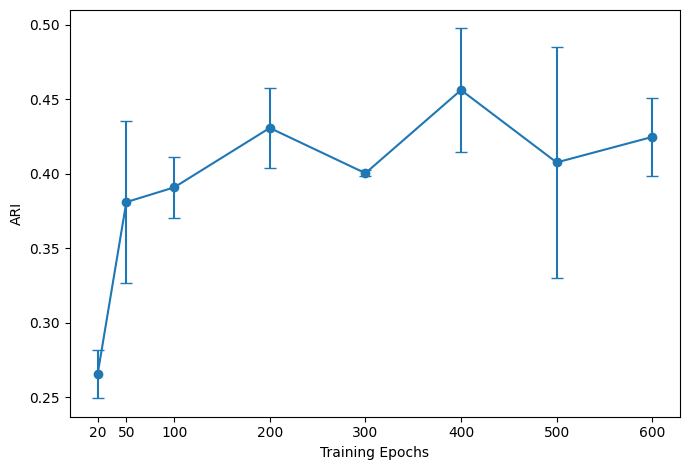

In [48]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(7, 4.8)
)

plt.errorbar(
    e185_summary600_df["epoch"],
    e185_summary600_df["ARI_mean"],
    yerr=e185_summary600_df["ARI_std"],
    marker="o",
    capsize=4,
    linewidth=1.5,
)

plt.xticks(
    E185_ALL_EPOCHS
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "ARI"
)

plt.tight_layout()

ARI600_PNG = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_ARI_600.png"
)

ARI600_PDF = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_ARI_600.pdf"
)

plt.savefig(
    ARI600_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    ARI600_PDF,
    bbox_inches="tight",
)

plt.show()

Cell 38：画 E18.5 NMI 20→600

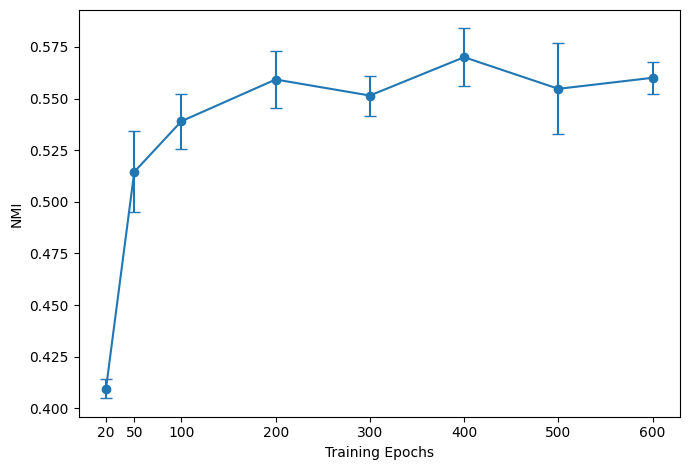

In [49]:
plt.figure(
    figsize=(7, 4.8)
)

plt.errorbar(
    e185_summary600_df["epoch"],
    e185_summary600_df["NMI_mean"],
    yerr=e185_summary600_df["NMI_std"],
    marker="o",
    capsize=4,
    linewidth=1.5,
)

plt.xticks(
    E185_ALL_EPOCHS
)

plt.xlabel(
    "Training Epochs"
)

plt.ylabel(
    "NMI"
)

plt.tight_layout()

NMI600_PNG = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_NMI_600.png"
)

NMI600_PDF = (
    E185_600_SUMMARY_DIR
    / "e185_epoch_sensitivity_NMI_600.pdf"
)

plt.savefig(
    NMI600_PNG,
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    NMI600_PDF,
    bbox_inches="tight",
)

plt.show()

Cell 39：重点看 300→400→500→600

In [50]:
d = (
    e185_summary600_df
    .set_index(
        "epoch"
    )
)

late_rows = []

for a, b in [
    (300, 400),
    (400, 500),
    (500, 600),
    (400, 600),
]:

    late_rows.append(
        {
            "from_epoch": a,
            "to_epoch": b,

            "delta_ARI": (
                d.loc[b, "ARI_mean"]
                -
                d.loc[a, "ARI_mean"]
            ),

            "delta_NMI": (
                d.loc[b, "NMI_mean"]
                -
                d.loc[a, "NMI_mean"]
            ),
        }
    )


e185_late_delta_df = pd.DataFrame(
    late_rows
)

print(
    e185_late_delta_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.6f}",
    )
)

e185_late_delta_df.to_csv(
    E185_600_SUMMARY_DIR
    / "e185_300_400_500_600_deltas.csv",
    index=False,
)

 from_epoch  to_epoch  delta_ARI  delta_NMI
        300       400  +0.055852  +0.018575
        400       500  -0.048617  -0.015329
        500       600  +0.017124  +0.005342
        400       600  -0.031493  -0.009987


Cell 40：查看最高 epoch，但只作诊断

In [51]:
ari_best = (
    e185_summary600_df.loc[
        e185_summary600_df[
            "ARI_mean"
        ].idxmax()
    ]
)

nmi_best = (
    e185_summary600_df.loc[
        e185_summary600_df[
            "NMI_mean"
        ].idxmax()
    ]
)

print(
    "Best mean ARI:"
)

print(
    f"epoch {int(ari_best['epoch'])} | "
    f"{ari_best['ARI_mean']:.6f} "
    f"± {ari_best['ARI_std']:.6f}"
)

print(
    "\nBest mean NMI:"
)

print(
    f"epoch {int(nmi_best['epoch'])} | "
    f"{nmi_best['NMI_mean']:.6f} "
    f"± {nmi_best['NMI_std']:.6f}"
)

print(
    "\nDiagnostic only."
)

print(
    "Do not select dataset-specific "
    "training epochs using GT metrics."
)

Best mean ARI:
epoch 400 | 0.456175 ± 0.041329

Best mean NMI:
epoch 400 | 0.570051 ± 0.013893

Diagnostic only.
Do not select dataset-specific training epochs using GT metrics.


Cell 41：归档 E18.5 600 结果

In [52]:
import shutil
from pathlib import Path

ARCHIVE600_DIR = (
    Path("/kaggle/working")
    / "SpaMGCL_E18.5_epoch600_archive"
)

if ARCHIVE600_DIR.exists():

    shutil.rmtree(
        ARCHIVE600_DIR
    )

ARCHIVE600_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Configs
# ============================================================

config_out = (
    ARCHIVE600_DIR
    / "configs"
)

config_out.mkdir(
    parents=True,
    exist_ok=True,
)

for p in E185_600_CONFIGS:

    shutil.copy2(
        p,
        config_out / p.name,
    )


# ============================================================
# Runner
# ============================================================

code_out = (
    ARCHIVE600_DIR
    / "code"
)

code_out.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copy2(
    RUNNER_600,
    code_out
    / RUNNER_600.name,
)


# ============================================================
# 500 / 600 results
# ============================================================

result_out = (
    ARCHIVE600_DIR
    / "results"
)

result_out.mkdir(
    parents=True,
    exist_ok=True,
)

for seed in E185_SEEDS:

    name = (
        f"sens_e185_seed{seed}_600ep"
    )

    src_dir = (
        E185_600_RESULT_ROOT
        / name
    )

    dst_dir = (
        result_out
        / name
    )

    dst_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    files_to_keep = [
        "metrics_epoch500.json",
        "metrics_epoch600.json",
        "metrics.json",
        "checkpoint_epoch600.pt",
    ]

    for filename in files_to_keep:

        src = (
            src_dir
            / filename
        )

        assert src.exists(), src

        shutil.copy2(
            src,
            dst_dir
            / filename,
        )


# ============================================================
# Summary
# ============================================================

shutil.copytree(
    E185_600_SUMMARY_DIR,
    ARCHIVE600_DIR
    / "summary",
    dirs_exist_ok=True,
)


# ============================================================
# ZIP
# ============================================================

ZIP600_BASE = Path(
    "/kaggle/working/"
    "SpaMGCL_E18.5_3seeds_epoch600"
)

ZIP600_PATH = shutil.make_archive(
    str(ZIP600_BASE),
    "zip",
    root_dir=ARCHIVE600_DIR,
)

ZIP600_PATH = Path(
    ZIP600_PATH
)

print(
    "Archive:"
)

print(
    ZIP600_PATH
)

print(
    "\nSize (MB):",
    round(
        ZIP600_PATH.stat().st_size
        / 1024
        / 1024,
        2,
    ),
)

print(
    "\nPASS: E18.5 epoch-600 "
    "continuation archived."
)

Archive:
/kaggle/working/SpaMGCL_E18.5_3seeds_epoch600.zip

Size (MB): 12.2

PASS: E18.5 epoch-600 continuation archived.


HLN-D1 + S2-E15

seeds = 0,1,2

epochs = 20 / 50 / 100 / 200 / 300 / 400

Cell 42：定义剩余两个数据集

In [53]:
# ============================================================
# Cell 42
# Remaining datasets:
# HLN-D1 + S2-E15
# 3 seeds × 400 epochs
# ============================================================

from pathlib import Path

REMAIN_DATASETS = [
    "HLN-D1",
    "S2-E15",
]

REMAIN_SEEDS = [
    0,
    1,
    2,
]

REMAIN_MILESTONES = [
    20,
    50,
    100,
    200,
    300,
    400,
]

REMAIN_SLUG = {
    "HLN-D1": "d1",
    "S2-E15": "s2e15",
}

REMAIN_CLUSTERS = {
    "HLN-D1": 11,
    "S2-E15": 15,
}


REMAIN_CONFIG_DIR = (
    PROJECT_ROOT
    / "configs"
    / "epoch_sensitivity_remaining_400"
)

REMAIN_RESULT_ROOT = (
    PROJECT_ROOT
    / "results_sensitivity_remaining_400"
)

REMAIN_SUMMARY_DIR = (
    PROJECT_ROOT
    / "sensitivity_summary_remaining_400"
)

REMAIN_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REMAIN_RESULT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

REMAIN_SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


BASE_REMAIN_CONFIGS = {
    "HLN-D1":
        PROJECT_ROOT
        / "configs"
        / "final_clean"
        / "d1_clean_200.yaml",

    "S2-E15":
        PROJECT_ROOT
        / "configs"
        / "final_clean"
        / "s2e15_clean_200.yaml",
}


for dataset, path in BASE_REMAIN_CONFIGS.items():

    assert path.exists(), (
        f"Missing base config: {path}"
    )

    print(
        dataset,
        "->",
        path.name,
    )


print(
    "\nPASS: remaining-dataset paths ready."
)

HLN-D1 -> d1_clean_200.yaml
S2-E15 -> s2e15_clean_200.yaml

PASS: remaining-dataset paths ready.


Cell 43：检查 400-epoch runner 可以直接从头训练

In [54]:
# ============================================================
# Cell 43
# Reuse validated 400-epoch runner
# ============================================================

RUNNER_REMAIN = (
    PROJECT_ROOT
    / "experiments"
    / "run_exp_resume_sensitivity.py"
)

assert RUNNER_REMAIN.exists(), RUNNER_REMAIN

runner_text = RUNNER_REMAIN.read_text(
    encoding="utf-8"
)

assert (
    "{20, 50, 100, 200, 300, 400}"
    in runner_text
)

assert (
    "range(start_epoch, epochs)"
    in runner_text
)

print(
    "Runner:",
    RUNNER_REMAIN
)

print(
    "\nPASS: runner supports "
    "20/50/100/200/300/400."
)

Runner: /kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_sensitivity.py

PASS: runner supports 20/50/100/200/300/400.


Cell 44：生成 6 个配置

epochs       = 400

warm_up      = 10

concat_z

KMeans n_init=20

KMeans rs    =0

BSRR k       =3

In [55]:
# ============================================================
# Cell 44
# Generate:
#   HLN-D1  seed 0/1/2
#   S2-E15  seed 0/1/2
# ============================================================

import copy
import yaml

REMAIN_CONFIGS = []

DATA_ROOT = Path(
    "/kaggle/input/datasets/wuvdji/smgc-data"
)

assert DATA_ROOT.exists(), DATA_ROOT


for dataset in REMAIN_DATASETS:

    slug = REMAIN_SLUG[
        dataset
    ]

    base_config_path = (
        BASE_REMAIN_CONFIGS[
            dataset
        ]
    )

    with base_config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        base_cfg = yaml.safe_load(f)


    for seed in REMAIN_SEEDS:

        cfg = copy.deepcopy(
            base_cfg
        )

        name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        # ----------------------------------------------
        # Experiment
        # ----------------------------------------------

        cfg[
            "experiment"
        ]["name"] = name

        cfg[
            "experiment"
        ]["dataset"] = dataset

        cfg[
            "experiment"
        ]["seed"] = seed

        if (
            "epochs"
            in cfg["experiment"]
        ):
            cfg[
                "experiment"
            ]["epochs"] = 400


        # ----------------------------------------------
        # Training
        # ----------------------------------------------

        cfg[
            "training"
        ]["epochs"] = 400

        if (
            "seed"
            in cfg["training"]
        ):
            cfg[
                "training"
            ]["seed"] = seed

        # Important:
        # these are fresh runs, not resume.
        cfg[
            "training"
        ].pop(
            "resume_from",
            None,
        )


        # ----------------------------------------------
        # Kaggle data
        # ----------------------------------------------

        cfg[
            "data"
        ]["root"] = str(
            DATA_ROOT
        )


        # ----------------------------------------------
        # Output
        # ----------------------------------------------

        cfg[
            "output"
        ]["root"] = (
            "results_sensitivity_remaining_400"
        )


        # ----------------------------------------------
        # Frozen protocol assertions
        # ----------------------------------------------

        assert (
            cfg["clustering"][
                "method"
            ].lower()
            == "kmeans"
        )

        assert (
            cfg["clustering"][
                "embedding"
            ].lower()
            == "concat_z"
        )

        assert (
            int(
                cfg["clustering"][
                    "n_clusters"
                ]
            )
            ==
            REMAIN_CLUSTERS[
                dataset
            ]
        )

        assert (
            int(
                cfg["clustering"][
                    "n_init"
                ]
            )
            == 20
        )

        assert (
            int(
                cfg["clustering"][
                    "random_state"
                ]
            )
            == 0
        )

        assert (
            cfg["refinement"][
                "method"
            ].lower()
            == "bsrr"
        )

        assert (
            int(
                cfg["refinement"][
                    "spatial_k"
                ]
            )
            == 3
        )


        config_path = (
            REMAIN_CONFIG_DIR
            / f"{name}.yaml"
        )

        with config_path.open(
            "w",
            encoding="utf-8",
        ) as f:

            yaml.safe_dump(
                cfg,
                f,
                sort_keys=False,
                allow_unicode=True,
            )

        REMAIN_CONFIGS.append(
            config_path
        )


assert len(
    REMAIN_CONFIGS
) == 6


print(
    "Generated configs:"
)

for p in sorted(
    REMAIN_CONFIGS
):
    print(
        " -",
        p.name,
    )


print(
    "\nPASS: 6 remaining sensitivity "
    "configs generated."
)

Generated configs:
 - sens_d1_seed0_400ep.yaml
 - sens_d1_seed1_400ep.yaml
 - sens_d1_seed2_400ep.yaml
 - sens_s2e15_seed0_400ep.yaml
 - sens_s2e15_seed1_400ep.yaml
 - sens_s2e15_seed2_400ep.yaml

PASS: 6 remaining sensitivity configs generated.


Cell 45：正式训练前审计

In [56]:
# ============================================================
# Cell 45
# Protocol audit
# ============================================================

import pandas as pd

audit_rows = []


for config_path in sorted(
    REMAIN_CONFIGS
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)


    dataset = (
        cfg["experiment"][
            "dataset"
        ]
    )

    training_cfg = (
        cfg["training"]
    )

    audit_rows.append(
        {
            "dataset":
                dataset,

            "seed":
                int(
                    cfg["experiment"][
                        "seed"
                    ]
                ),

            "epochs":
                int(
                    training_cfg[
                        "epochs"
                    ]
                ),

            "warm_up":
                int(
                    training_cfg[
                        "warm_up_epochs"
                    ]
                ),

            "K":
                int(
                    cfg["clustering"][
                        "n_clusters"
                    ]
                ),

            "embedding":
                cfg["clustering"][
                    "embedding"
                ],

            "n_init":
                int(
                    cfg["clustering"][
                        "n_init"
                    ]
                ),

            "kmeans_rs":
                int(
                    cfg["clustering"][
                        "random_state"
                    ]
                ),

            "refinement":
                cfg["refinement"][
                    "method"
                ],

            "spatial_k":
                int(
                    cfg["refinement"][
                        "spatial_k"
                    ]
                ),

            "resume":
                training_cfg.get(
                    "resume_from",
                    None,
                ),
        }
    )


remain_audit_df = pd.DataFrame(
    audit_rows
)

print(
    remain_audit_df.to_string(
        index=False
    )
)


assert (
    remain_audit_df[
        "epochs"
    ] == 400
).all()

assert (
    remain_audit_df[
        "warm_up"
    ] == 10
).all()

assert (
    remain_audit_df[
        "embedding"
    ].str.lower()
    == "concat_z"
).all()

assert (
    remain_audit_df[
        "n_init"
    ] == 20
).all()

assert (
    remain_audit_df[
        "kmeans_rs"
    ] == 0
).all()

assert (
    remain_audit_df[
        "refinement"
    ].str.lower()
    == "bsrr"
).all()

assert (
    remain_audit_df[
        "spatial_k"
    ] == 3
).all()

assert (
    remain_audit_df[
        "resume"
    ].isna()
).all()


print(
    "\nPASS: HLN-D1 + S2-E15 "
    "protocol frozen."
)

dataset  seed  epochs  warm_up  K embedding  n_init  kmeans_rs refinement  spatial_k resume
 HLN-D1     0     400       10 11  concat_z      20          0       bsrr          3   None
 HLN-D1     1     400       10 11  concat_z      20          0       bsrr          3   None
 HLN-D1     2     400       10 11  concat_z      20          0       bsrr          3   None
 S2-E15     0     400       10 15  concat_z      20          0       bsrr          3   None
 S2-E15     1     400       10 15  concat_z      20          0       bsrr          3   None
 S2-E15     2     400       10 15  concat_z      20          0       bsrr          3   None

PASS: HLN-D1 + S2-E15 protocol frozen.


Cell 46：跑 6 次训练

In [57]:
# ============================================================
# Cell 46
# Run 6 sensitivity experiments
# ============================================================

import shutil
import subprocess
import sys


TOTAL_RUNS = len(
    REMAIN_CONFIGS
)

assert TOTAL_RUNS == 6


for idx, config_path in enumerate(
    sorted(REMAIN_CONFIGS),
    start=1,
):

    with config_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        cfg = yaml.safe_load(f)


    exp_name = (
        cfg["experiment"][
            "name"
        ]
    )

    dataset = (
        cfg["experiment"][
            "dataset"
        ]
    )

    seed = int(
        cfg["experiment"][
            "seed"
        ]
    )


    output_dir = (
        REMAIN_RESULT_ROOT
        / exp_name
    )


    required_files = [
        output_dir
        / f"metrics_epoch{epoch}.json"
        for epoch
        in REMAIN_MILESTONES
    ]

    required_files.extend(
        [
            output_dir
            / "metrics.json",

            output_dir
            / "checkpoint_epoch400.pt",
        ]
    )


    print(
        "\n" + "=" * 80
    )

    print(
        f"[{idx}/{TOTAL_RUNS}]"
    )

    print(
        "Dataset :",
        dataset,
    )

    print(
        "Seed    :",
        seed,
    )

    print(
        "Name    :",
        exp_name,
    )

    print(
        "Epochs  : 400"
    )

    print(
        "Output  :",
        output_dir,
    )

    print(
        "=" * 80
    )


    # ========================================================
    # Complete -> skip
    # ========================================================

    if all(
        p.exists()
        for p in required_files
    ):

        print(
            "SKIP: complete result "
            "already exists."
        )

        continue


    # ========================================================
    # Existing partial directory
    # ========================================================

    if output_dir.exists():

        metric_files = list(
            output_dir.glob(
                "metrics*.json"
            )
        )

        checkpoint_files = list(
            output_dir.glob(
                "checkpoint_epoch*.pt"
            )
        )


        # ----------------------------------------------
        # Real training already happened
        # ----------------------------------------------

        if (
            metric_files
            or checkpoint_files
        ):

            print(
                "\nPartial TRAINED "
                "result detected:"
            )

            for p in sorted(
                output_dir.iterdir()
            )[:40]:

                print(
                    " -",
                    p.name,
                )


            raise RuntimeError(
                "\nSTOP: partial trained "
                "run detected.\n"
                f"{output_dir}\n"
                "Do not overwrite automatically."
            )


        # ----------------------------------------------
        # Only manifest/config residue
        # ----------------------------------------------

        print(
            "\nPre-training residue detected."
        )

        for p in sorted(
            output_dir.iterdir()
        ):

            print(
                " -",
                p.name,
            )


        print(
            "\nRemoving safe residue..."
        )

        shutil.rmtree(
            output_dir
        )

        print(
            "PASS: residue removed."
        )


    # ========================================================
    # Run from epoch 1
    # ========================================================

    cmd = [
        sys.executable,
        str(RUNNER_REMAIN),
        "--config",
        str(config_path),
    ]


    print(
        "\nRunning:"
    )

    print(
        " ".join(cmd)
    )

    print()


    subprocess.run(
        cmd,
        cwd=PROJECT_ROOT,
        check=True,
    )


    # ========================================================
    # Audit outputs
    # ========================================================

    for p in required_files:

        assert p.exists(), (
            f"Missing result: {p}"
        )


    print(
        "\nPASS:",
        exp_name,
    )


print(
    "\n" + "=" * 80
)

print(
    "PASS: all 6 remaining "
    "sensitivity runs completed."
)

print(
    "=" * 80
)


[1/6]
Dataset : HLN-D1
Seed    : 0
Name    : sens_d1_seed0_400ep
Epochs  : 400
Output  : /kaggle/working/SpaMGCL/SpaMGCL/results_sensitivity_remaining_400/sens_d1_seed0_400ep

Running:
/usr/bin/python3 /kaggle/working/SpaMGCL/SpaMGCL/experiments/run_exp_resume_sensitivity.py --config /kaggle/working/SpaMGCL/SpaMGCL/configs/epoch_sensitivity_remaining_400/sens_d1_seed0_400ep.yaml



/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: HLN-D1 | spots=3359 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3359, 3359), nnz=12744
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/400 | total=8.370173 | rec=0.248054 | mgcl=8.122119 | cluster=3.050508 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.870e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.952 | gradC=0.000e+00
epoch 002/400 | total=8.359020 | rec=0.238144 | mgcl=8.120875 | cluster=3.049739 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.930e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.958 | gradC=0.000e+00
epoch 003/400 | total=8.348646 | rec=0.228612 | mgcl=8.120034 | cluster=3.049047 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.583e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.963 | gradC=0.000e+00
epoch

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: HLN-D1 | spots=3359 | device=cuda
Modalities: RNA, ADT | label=Spatial_Label
Spatial graph: shape=(3359, 3359), nnz=12744
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/400 | total=8.349872 | rec=0.226992 | mgcl=8.122880 | cluster=3.048808 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.623e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.970 | gradC=0.000e+00
epoch 002/400 | total=8.339814 | rec=0.218547 | mgcl=8.121267 | cluster=3.048234 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.568e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.975 | gradC=0.000e+00
epoch 003/400 | total=8.330776 | rec=0.210469 | mgcl=8.120308 | cluster=3.047729 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=2.795e-03 | neg_count=11279522 | snf_masked_positions=0 | effC=10.978 | gradC=0.000e+00
epoch

...

Dataset: S2-E15 | spots=1939 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(1939, 1939), nnz=7062
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/400 | total=22.891996 | rec=0.165808 | mgcl=7.575396 | cluster=3.369660 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=8.919e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.972 | gradC=0.000e+00
epoch 002/400 | total=22.847919 | rec=0.153040 | mgcl=7.564960 | cluster=3.369064 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=7.980e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.979 | gradC=0.000e+00
epoch 003/400 | total=22.801908 | rec=0.141745 | mgcl=7.553388 | cluster=3.368593 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=7.761e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.985 | gradC=0.000e+00
epoch

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: S2-E15 | spots=1939 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(1939, 1939), nnz=7062
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/400 | total=22.889145 | rec=0.161898 | mgcl=7.575749 | cluster=3.369750 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=5.955e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.974 | gradC=0.000e+00
epoch 002/400 | total=22.842104 | rec=0.149705 | mgcl=7.564133 | cluster=3.369132 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=4.816e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.980 | gradC=0.000e+00
epoch 003/400 | total=22.789711 | rec=0.138926 | mgcl=7.550262 | cluster=3.368660 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=6.825e-03 | neg_count=3757782 | snf_masked_positions=0 | effC=14.985 | gradC=0.000e+00
epoch

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Dataset: S2-E15 | spots=1939 | device=cuda
Modalities: RNA, ATAC | label=Spatial_Label
Spatial graph: shape=(1939, 1939), nnz=7062
Learning rates: backbone=0.001 | cluster_head=0.008 (8x)
epoch 001/400 | total=22.882629 | rec=0.158348 | mgcl=7.574760 | cluster=3.368811 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.144e-02 | neg_count=3757782 | snf_masked_positions=0 | effC=14.980 | gradC=0.000e+00
epoch 002/400 | total=22.846924 | rec=0.146510 | mgcl=7.566804 | cluster=3.368489 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.124e-02 | neg_count=3757782 | snf_masked_positions=0 | effC=14.984 | gradC=0.000e+00
epoch 003/400 | total=22.813124 | rec=0.135625 | mgcl=7.559166 | cluster=3.368209 | spatial_loss=0.000000 | lambda_spatial=0 | sc_enabled=False | snf_enabled=False | mgcl_weight_std=1.088e-02 | neg_count=3757782 | snf_masked_positions=0 | effC=14.987 | gradC=0.000e+00
epoch

Cell 47：读取 36 行原始结果

In [58]:
# ============================================================
# Cell 47
# Collect 36 raw rows
# ============================================================

import json

rows = []


for dataset in REMAIN_DATASETS:

    slug = REMAIN_SLUG[
        dataset
    ]


    for seed in REMAIN_SEEDS:

        name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        run_dir = (
            REMAIN_RESULT_ROOT
            / name
        )


        for epoch in REMAIN_MILESTONES:

            path = (
                run_dir
                / f"metrics_epoch{epoch}.json"
            )

            assert path.exists(), path


            with path.open(
                "r",
                encoding="utf-8",
            ) as f:

                m = json.load(f)


            rows.append(
                {
                    "dataset":
                        dataset,

                    "seed":
                        seed,

                    "epoch":
                        epoch,

                    "ARI":
                        float(
                            m["ARI"]
                        ),

                    "NMI":
                        float(
                            m["NMI"]
                        ),
                }
            )


remain_raw_df = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "dataset",
            "seed",
            "epoch",
        ]
    )
    .reset_index(
        drop=True
    )
)


assert len(
    remain_raw_df
) == 36


print(
    remain_raw_df.to_string(
        index=False
    )
)


REMAIN_RAW_CSV = (
    REMAIN_SUMMARY_DIR
    / "remaining_epoch_sensitivity_raw_36rows.csv"
)

remain_raw_df.to_csv(
    REMAIN_RAW_CSV,
    index=False,
)


print(
    "\nPASS: 36 raw rows collected."
)

dataset  seed  epoch      ARI      NMI
 HLN-D1     0     20 0.166891 0.185726
 HLN-D1     0     50 0.188883 0.253237
 HLN-D1     0    100 0.235535 0.308736
 HLN-D1     0    200 0.262488 0.344039
 HLN-D1     0    300 0.251444 0.336789
 HLN-D1     0    400 0.257788 0.344006
 HLN-D1     1     20 0.154891 0.230634
 HLN-D1     1     50 0.170428 0.251694
 HLN-D1     1    100 0.213234 0.302491
 HLN-D1     1    200 0.221046 0.309486
 HLN-D1     1    300 0.249031 0.336391
 HLN-D1     1    400 0.239834 0.327662
 HLN-D1     2     20 0.182696 0.225513
 HLN-D1     2     50 0.265100 0.342248
 HLN-D1     2    100 0.240006 0.325998
 HLN-D1     2    200 0.232441 0.329435
 HLN-D1     2    300 0.267459 0.350288
 HLN-D1     2    400 0.238614 0.331083
 S2-E15     0     20 0.234722 0.435069
 S2-E15     0     50 0.336811 0.531744
 S2-E15     0    100 0.337142 0.549784
 S2-E15     0    200 0.331247 0.542055
 S2-E15     0    300 0.388722 0.569908
 S2-E15     0    400 0.362805 0.557261
 S2-E15     1     20 0.30

Cell 48：计算 mean ± std

In [59]:
# ============================================================
# Cell 48
# Mean ± std over 3 seeds
# ============================================================

import numpy as np

summary_rows = []


for (
    dataset,
    epoch,
), g in remain_raw_df.groupby(
    [
        "dataset",
        "epoch",
    ],
    sort=False,
):

    ari = g[
        "ARI"
    ].to_numpy(
        dtype=float
    )

    nmi = g[
        "NMI"
    ].to_numpy(
        dtype=float
    )


    assert len(ari) == 3
    assert len(nmi) == 3


    summary_rows.append(
        {
            "dataset":
                dataset,

            "epoch":
                int(epoch),

            "ARI_mean":
                float(
                    np.mean(ari)
                ),

            "ARI_std":
                float(
                    np.std(
                        ari,
                        ddof=0,
                    )
                ),

            "NMI_mean":
                float(
                    np.mean(nmi)
                ),

            "NMI_std":
                float(
                    np.std(
                        nmi,
                        ddof=0,
                    )
                ),
        }
    )


remain_summary_df = pd.DataFrame(
    summary_rows
)


order = {
    "HLN-D1": 0,
    "S2-E15": 1,
}

remain_summary_df[
    "_order"
] = (
    remain_summary_df[
        "dataset"
    ].map(
        order
    )
)

remain_summary_df = (
    remain_summary_df
    .sort_values(
        [
            "_order",
            "epoch",
        ]
    )
    .drop(
        columns="_order"
    )
    .reset_index(
        drop=True
    )
)


print(
    "=" * 100
)

print(
    "REMAINING DATASETS EPOCH SENSITIVITY"
)

print(
    "=" * 100
)


for _, r in (
    remain_summary_df.iterrows()
):

    print(
        f"{r['dataset']:8s} | "
        f"epoch "
        f"{int(r['epoch']):>3d} | "
        f"ARI = "
        f"{r['ARI_mean']:.6f} "
        f"± "
        f"{r['ARI_std']:.6f} | "
        f"NMI = "
        f"{r['NMI_mean']:.6f} "
        f"± "
        f"{r['NMI_std']:.6f}"
    )


REMAIN_SUMMARY_CSV = (
    REMAIN_SUMMARY_DIR
    / "remaining_epoch_sensitivity_summary.csv"
)

remain_summary_df.to_csv(
    REMAIN_SUMMARY_CSV,
    index=False,
)


print(
    "\nSaved:"
)

print(
    REMAIN_SUMMARY_CSV
)

REMAINING DATASETS EPOCH SENSITIVITY
HLN-D1   | epoch  20 | ARI = 0.168159 ± 0.011387 | NMI = 0.213958 ± 0.020072
HLN-D1   | epoch  50 | ARI = 0.208137 ± 0.040977 | NMI = 0.282393 ± 0.042329
HLN-D1   | epoch 100 | ARI = 0.229591 ± 0.011710 | NMI = 0.312408 ± 0.009942
HLN-D1   | epoch 200 | ARI = 0.238658 ± 0.017480 | NMI = 0.327654 ± 0.014162
HLN-D1   | epoch 300 | ARI = 0.255978 ± 0.008178 | NMI = 0.341156 ± 0.006460
HLN-D1   | epoch 400 | ARI = 0.245412 ± 0.008765 | NMI = 0.334250 ± 0.007038
S2-E15   | epoch  20 | ARI = 0.292124 ± 0.043939 | NMI = 0.477336 ± 0.034305
S2-E15   | epoch  50 | ARI = 0.376127 ± 0.035228 | NMI = 0.547217 ± 0.013669
S2-E15   | epoch 100 | ARI = 0.365957 ± 0.038388 | NMI = 0.557006 ± 0.012602
S2-E15   | epoch 200 | ARI = 0.365205 ± 0.031160 | NMI = 0.556990 ± 0.010561
S2-E15   | epoch 300 | ARI = 0.385162 ± 0.018138 | NMI = 0.574913 ± 0.009144
S2-E15   | epoch 400 | ARI = 0.380687 ± 0.020002 | NMI = 0.561982 ± 0.003559

Saved:
/kaggle/working/SpaMGCL/SpaMGCL

Cell 49：看 200→300→400 是否进入平台

In [60]:
# ============================================================
# Cell 49
# Late-stage trend diagnostic
# ============================================================

late_rows = []


for dataset in REMAIN_DATASETS:

    d = (
        remain_summary_df[
            remain_summary_df[
                "dataset"
            ] == dataset
        ]
        .set_index(
            "epoch"
        )
    )


    for a, b in [
        (200, 300),
        (300, 400),
        (200, 400),
    ]:

        late_rows.append(
            {
                "dataset":
                    dataset,

                "from_epoch":
                    a,

                "to_epoch":
                    b,

                "delta_ARI":
                    (
                        d.loc[
                            b,
                            "ARI_mean",
                        ]
                        -
                        d.loc[
                            a,
                            "ARI_mean",
                        ]
                    ),

                "delta_NMI":
                    (
                        d.loc[
                            b,
                            "NMI_mean",
                        ]
                        -
                        d.loc[
                            a,
                            "NMI_mean",
                        ]
                    ),
            }
        )


remain_delta_df = pd.DataFrame(
    late_rows
)


print(
    remain_delta_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.6f}",
    )
)


remain_delta_df.to_csv(
    REMAIN_SUMMARY_DIR
    / "remaining_200_300_400_deltas.csv",
    index=False,
)

dataset  from_epoch  to_epoch  delta_ARI  delta_NMI
 HLN-D1         200       300  +0.017320  +0.013502
 HLN-D1         300       400  -0.010566  -0.006905
 HLN-D1         200       400  +0.006754  +0.006597
 S2-E15         200       300  +0.019958  +0.017923
 S2-E15         300       400  -0.004476  -0.012932
 S2-E15         200       400  +0.015482  +0.004991


Cell 50：诊断最高 epoch

In [61]:
# ============================================================
# Cell 50
# Diagnostic best epoch
# ============================================================

best_rows = []


for dataset in REMAIN_DATASETS:

    d = remain_summary_df[
        remain_summary_df[
            "dataset"
        ] == dataset
    ]


    ari_best = d.loc[
        d["ARI_mean"].idxmax()
    ]

    nmi_best = d.loc[
        d["NMI_mean"].idxmax()
    ]


    best_rows.append(
        {
            "dataset":
                dataset,

            "best_ARI_epoch":
                int(
                    ari_best[
                        "epoch"
                    ]
                ),

            "best_ARI":
                float(
                    ari_best[
                        "ARI_mean"
                    ]
                ),

            "best_NMI_epoch":
                int(
                    nmi_best[
                        "epoch"
                    ]
                ),

            "best_NMI":
                float(
                    nmi_best[
                        "NMI_mean"
                    ]
                ),
        }
    )


remain_best_df = pd.DataFrame(
    best_rows
)


print(
    remain_best_df.to_string(
        index=False
    )
)


print(
    "\nDiagnostic only — "
    "do not select a different "
    "epoch for each dataset."
)

dataset  best_ARI_epoch  best_ARI  best_NMI_epoch  best_NMI
 HLN-D1             300  0.255978             300  0.341156
 S2-E15             300  0.385162             300  0.574913

Diagnostic only — do not select a different epoch for each dataset.


Cell 51：归档两个数据集

In [62]:
# ============================================================
# Cell 51
# Archive remaining datasets
# ============================================================

import shutil


REMAIN_ARCHIVE_DIR = (
    Path("/kaggle/working")
    / "SpaMGCL_remaining_2datasets_epoch400_archive"
)


if REMAIN_ARCHIVE_DIR.exists():

    shutil.rmtree(
        REMAIN_ARCHIVE_DIR
    )


REMAIN_ARCHIVE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Configs
# ============================================================

config_out = (
    REMAIN_ARCHIVE_DIR
    / "configs"
)

config_out.mkdir(
    parents=True,
    exist_ok=True,
)


for p in REMAIN_CONFIGS:

    shutil.copy2(
        p,
        config_out
        / p.name,
    )


# ============================================================
# Runner
# ============================================================

code_out = (
    REMAIN_ARCHIVE_DIR
    / "code"
)

code_out.mkdir(
    parents=True,
    exist_ok=True,
)


shutil.copy2(
    RUNNER_REMAIN,
    code_out
    / RUNNER_REMAIN.name,
)


# ============================================================
# Results
# ============================================================

result_out = (
    REMAIN_ARCHIVE_DIR
    / "results"
)

result_out.mkdir(
    parents=True,
    exist_ok=True,
)


for dataset in REMAIN_DATASETS:

    slug = REMAIN_SLUG[
        dataset
    ]


    for seed in REMAIN_SEEDS:

        name = (
            f"sens_{slug}_"
            f"seed{seed}_400ep"
        )

        src_dir = (
            REMAIN_RESULT_ROOT
            / name
        )

        dst_dir = (
            result_out
            / name
        )

        dst_dir.mkdir(
            parents=True,
            exist_ok=True,
        )


        files_to_keep = [
            "metrics_epoch20.json",
            "metrics_epoch50.json",
            "metrics_epoch100.json",
            "metrics_epoch200.json",
            "metrics_epoch300.json",
            "metrics_epoch400.json",
            "metrics.json",
            "checkpoint_epoch400.pt",
        ]


        for filename in files_to_keep:

            src = (
                src_dir
                / filename
            )

            assert src.exists(), src

            shutil.copy2(
                src,
                dst_dir
                / filename,
            )


# ============================================================
# Summary
# ============================================================

shutil.copytree(
    REMAIN_SUMMARY_DIR,
    REMAIN_ARCHIVE_DIR
    / "summary",
    dirs_exist_ok=True,
)


# ============================================================
# ZIP
# ============================================================

REMAIN_ZIP_BASE = Path(
    "/kaggle/working/"
    "SpaMGCL_HLND1_S2E15_3seeds_epoch400"
)


REMAIN_ZIP_PATH = shutil.make_archive(
    str(
        REMAIN_ZIP_BASE
    ),
    "zip",
    root_dir=REMAIN_ARCHIVE_DIR,
)


REMAIN_ZIP_PATH = Path(
    REMAIN_ZIP_PATH
)


print(
    "Archive:"
)

print(
    REMAIN_ZIP_PATH
)


print(
    "\nSize (MB):",
    round(
        REMAIN_ZIP_PATH.stat().st_size
        / 1024
        / 1024,
        2,
    ),
)


print(
    "\nPASS: HLN-D1 + S2-E15 "
    "sensitivity archived."
)

Archive:
/kaggle/working/SpaMGCL_HLND1_S2E15_3seeds_epoch400.zip

Size (MB): 13.98

PASS: HLN-D1 + S2-E15 sensitivity archived.


# Epoch Sensitivity Study — Completed

This notebook completes the epoch-sensitivity analysis of SpaMGCL.

Datasets:
- HLN-A1
- HLN-D1
- E18.5
- S2-E15
- S2-E18

Sensitivity protocol:
- training seeds: 0, 1, 2
- warm-up: 10 epochs
- official readout: concat-Z → BSRR → KMeans
- BSRR spatial_k: 3
- KMeans n_init: 20
- KMeans random_state: 0

Main observations:
- HLN-A1 entered a high-performance plateau around 300–400 epochs.
- HLN-D1 entered a high-performance plateau around 300–400 epochs.
- S2-E15 entered a high-performance plateau around 300–400 epochs.
- S2-E18 entered a high-performance plateau around 300–400 epochs.
- E18.5 benefited from longer training up to the 400-epoch region, while
  extending training to 500–600 epochs did not produce consistent further gains.

Therefore, 400 epochs is retained as the unified candidate training budget for
the subsequent formal experiments. It is treated as a fixed training budget,
not as an exact dataset-specific optimum selected using ground-truth metrics.

The formal 10-seed benchmark will be conducted in a separate notebook.

Cell 52：最终归档审计 + 结束标记

In [63]:
# ============================================================
# Cell 52
# FINAL SENSITIVITY STUDY AUDIT
# ============================================================

from pathlib import Path
from datetime import datetime
import json


WORK_ROOT = Path(
    "/kaggle/working"
)

PROJECT_ROOT = Path(
    "/kaggle/working/SpaMGCL/SpaMGCL"
)


# ============================================================
# Required archives
# ============================================================

required_archives = {
    "stage_20_200": (
        WORK_ROOT
        / "SpaMGCL_epoch_sensitivity_3datasets_3seeds.zip"
    ),

    "stage_300_400": (
        WORK_ROOT
        / "SpaMGCL_epoch_sensitivity_3datasets_3seeds_400ep.zip"
    ),

    "e185_500_600": (
        WORK_ROOT
        / "SpaMGCL_E18.5_3seeds_epoch600.zip"
    ),

    "d1_s2e15_20_400": (
        WORK_ROOT
        / "SpaMGCL_HLND1_S2E15_3seeds_epoch400.zip"
    ),
}


print("=" * 90)
print("FINAL ARCHIVE AUDIT")
print("=" * 90)

archive_status = {}

for name, path in required_archives.items():

    exists = path.exists()

    size_mb = (
        path.stat().st_size
        / 1024
        / 1024
        if exists
        else None
    )

    archive_status[name] = {
        "path": str(path),
        "exists": exists,
        "size_mb": size_mb,
    }

    if exists:
        print(
            f"PASS | {name:<22s} | "
            f"{size_mb:8.2f} MB | "
            f"{path.name}"
        )
    else:
        print(
            f"MISS | {name:<22s} | "
            f"{path}"
        )


assert all(
    item["exists"]
    for item in archive_status.values()
), (
    "STOP: at least one sensitivity archive is missing."
)


# ============================================================
# Save final study manifest
# ============================================================

manifest = {
    "study": "SpaMGCL epoch sensitivity",
    "status": "completed",

    "datasets": [
        "HLN-A1",
        "HLN-D1",
        "E18.5",
        "S2-E15",
        "S2-E18",
    ],

    "training_seeds": [
        0,
        1,
        2,
    ],

    "protocol": {
        "warm_up_epochs": 10,
        "official_embedding": "concat_z",
        "refinement": "bsrr",
        "spatial_k": 3,
        "clustering": "kmeans",
        "kmeans_n_init": 20,
        "kmeans_random_state": 0,
    },

    "sensitivity_epochs": {
        "HLN-A1": [
            20, 50, 100, 200, 300, 400
        ],

        "HLN-D1": [
            20, 50, 100, 200, 300, 400
        ],

        "E18.5": [
            20, 50, 100, 200,
            300, 400, 500, 600
        ],

        "S2-E15": [
            20, 50, 100, 200, 300, 400
        ],

        "S2-E18": [
            20, 50, 100, 200, 300, 400
        ],
    },

    "conclusion": {
        "candidate_unified_epoch": 400,

        "interpretation": (
            "400 epochs is retained as a unified "
            "training-budget candidate. It is not "
            "interpreted as the exact optimal epoch."
        ),

        "formal_experiment_policy": (
            "Use one fixed epoch budget for all datasets "
            "and all training seeds; do not select "
            "dataset-specific or seed-specific checkpoints "
            "using ground-truth ARI/NMI."
        ),
    },

    "archives": archive_status,

    "completed_at": (
        datetime.now().isoformat(
            timespec="seconds"
        )
    ),
}


manifest_path = (
    WORK_ROOT
    / "SpaMGCL_epoch_sensitivity_FINAL_MANIFEST.json"
)

with manifest_path.open(
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


print()
print("Final manifest:")
print(manifest_path)

print()
print("=" * 90)
print("EPOCH SENSITIVITY STUDY: COMPLETE")
print("=" * 90)

print(
    "\nNext experiment:"
)

print(
    "SpaMGCL formal benchmark "
    "= 5 datasets × 10 seeds × "
    "fixed unified training budget."
)

print(
    "\nThis notebook should now be frozen."
)

print(
    "Do NOT add formal benchmark training "
    "to this notebook."
)

FINAL ARCHIVE AUDIT
PASS | stage_20_200           |     1.07 MB | SpaMGCL_epoch_sensitivity_3datasets_3seeds.zip
PASS | stage_300_400          |    25.79 MB | SpaMGCL_epoch_sensitivity_3datasets_3seeds_400ep.zip
PASS | e185_500_600           |    12.20 MB | SpaMGCL_E18.5_3seeds_epoch600.zip
PASS | d1_s2e15_20_400        |    13.98 MB | SpaMGCL_HLND1_S2E15_3seeds_epoch400.zip

Final manifest:
/kaggle/working/SpaMGCL_epoch_sensitivity_FINAL_MANIFEST.json

EPOCH SENSITIVITY STUDY: COMPLETE

Next experiment:
SpaMGCL formal benchmark = 5 datasets × 10 seeds × fixed unified training budget.

This notebook should now be frozen.
Do NOT add formal benchmark training to this notebook.
